In [2]:
import tiktoken
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import os
from tqdm.notebook import tqdm
import html

In [3]:
enc = tiktoken.get_encoding("gpt2")
vocab_size = enc.n_vocab

In [4]:
d_model = 768
n_heads = 12
d_head = 64 # changeables

vocab_size = enc.n_vocab
batch_size = 32
context_len = 128

lr = 3e-4

epochs = 40_000
eval_iters = 50
device = 'mps'
load_check_point = True
data_dir = os.path.join('../data', "openwebtext")

# Arrays to store data
step_history = []
# We need to store mean and std separately
train_history = {'mean': [], 'std': []}
val_history = {'mean': [], 'std': []}

In [5]:
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - context_len, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+context_len]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+context_len]).astype(np.int64)) for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [6]:
class Transformer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, n_heads: int, d_head: int, context_len: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head 
        self.context_len = context_len
        self.num_layers = 8 # Defined explicitly

        # Embeddings
        self.W_E = nn.Embedding(self.vocab_size, self.d_model)
        self.W_pos = nn.Embedding(context_len, d_model)

        # We use ModuleList to hold the weights for Layer 0 and Layer 1 separate
        self.W_Q = nn.ModuleList([nn.Linear(self.d_model, self.n_heads * self.d_head, bias=False) for _ in range(self.num_layers)])
        self.W_K = nn.ModuleList([nn.Linear(self.d_model, self.n_heads * self.d_head, bias=False) for _ in range(self.num_layers)])
        self.W_V = nn.ModuleList([nn.Linear(self.d_model, self.n_heads * self.d_head, bias=False) for _ in range(self.num_layers)])
        self.W_O = nn.ModuleList([nn.Linear(self.n_heads * self.d_head, self.d_model, bias=False) for _ in range(self.num_layers)])

        # Unembedding
        self.W_U = nn.Linear(self.d_model, self.vocab_size)
        
        # Initialize weights with Kaiming He initialization
        self._init_weights()

    def _init_weights(self):
        """Initialize weights using dimension-based normal initialization"""
        # Initialize embedding layers with normal distribution
        nn.init.normal_(self.W_E.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.W_pos.weight, mean=0.0, std=0.02)
        
        # Calculate dimensions
        d_k = self.n_heads * self.d_head  # output dimension for Q, K, V
        d_v = self.n_heads * self.d_head  # output dimension for V
        
        # Initialize all linear layers with dimension-based normal initialization
        for i in range(self.num_layers):
            nn.init.normal_(self.W_Q[i].weight, mean=0, std=np.sqrt(2.0 / (self.d_model + d_k)))
            nn.init.normal_(self.W_K[i].weight, mean=0, std=np.sqrt(2.0 / (self.d_model + d_k)))
            nn.init.normal_(self.W_V[i].weight, mean=0, std=np.sqrt(2.0 / (self.d_model + d_v)))
            nn.init.normal_(self.W_O[i].weight, mean=0, std=np.sqrt(2.0 / (d_k + self.d_model)))
        
        # Initialize unembedding layer: input d_model, output vocab_size
        nn.init.normal_(self.W_U.weight, mean=0, std=np.sqrt(2.0 / (self.d_model + self.vocab_size)))

    def forward(self, x: torch.Tensor, return_all: bool = False):
        device = x.device
        B, T = x.shape
        pos = torch.arange(T, device=device)
        
        # 1. Embedding
        x = self.W_E(x) + self.W_pos(pos)
        
        # Storage for visualization if return_all=True
        cache = {
            'scores': [],
            'pattern': [],
            'v': [],
            'z': [],
            'x': []
        }

        # 2. Loop over layers (Layer 0 then Layer 1)
        for i in range(self.num_layers):
            residual = x 
            
            # Calculate Q, K, V for this specific layer [i]
            q = self.W_Q[i](x) 
            k = self.W_K[i](x)  
            v = self.W_V[i](x)

            # Reshape for multi-head attention
            q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
            k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
            v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

            # Attention Scores
            scores = torch.matmul(q, k.transpose(-2, -1)) / self.d_head ** 0.5 
            
            # Masking
            mask = torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)
            scores = scores.masked_fill(mask, float('-inf'))
            
            # Softmax (Attention Pattern)
            pattern = F.softmax(scores, dim=-1)

            # Weighted Sum
            z = torch.matmul(pattern, v) 
            z = z.transpose(1, 2).contiguous().view(B, T, -1)
            
            # Output Projection
            attn_out = self.W_O[i](z)

            # Residual Connection (Crucial for deep networks)
            x = attn_out + residual
            
            # Save cache for this layer
            if return_all:
                cache['scores'].append(scores)
                cache['pattern'].append(pattern)
                cache['v'].append(v)
                cache['z'].append(z)
                cache['x'].append(x)

        # 3. Unembedding
        logits = self.W_U(x)

        if return_all:
            # We return lists containing the data for Layer 0 and Layer 1
            return logits, cache
            
        return logits

In [7]:
model = Transformer(
    vocab_size=vocab_size,
    d_model= d_model,
    n_heads=n_heads,
    d_head=d_head,
    context_len=context_len
)
model.to(device)

optim = optim.AdamW(model.parameters(), lr, betas=(0.9, 0.999))
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")
# Load checkpoint if needed
if load_check_point:
    checkpoint = torch.load('one_layer_transformer.pth', map_location=device)
    model.load_state_dict(checkpoint['model'])
    if 'optimizer' in checkpoint:
        optim.load_state_dict(checkpoint['optimizer'])


Total number of parameters: 96,217,681


In [8]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits = model(X)
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), Y.view(B*T))
            losses[k] = loss.item()
        
        # Calculate Mean and Standard Deviation
        out[split] = {
            'mean': losses.mean().item(),
            'std': losses.std().item()
        }
    model.train()
    return out

In [9]:
pbar = tqdm(range(2), desc="Training Model")

for epoch in pbar:

    if epoch % 3000 == 0 and epoch != 0:
        stats = estimate_loss()
        step_history.append(epoch)
        train_history['mean'].append(stats['train']['mean'])
        train_history['std'].append(stats['train']['std'])
        val_history['mean'].append(stats['val']['mean'])
        val_history['std'].append(stats['val']['std'])
        
        print(f"step {epoch}: val loss {stats['val']['mean']:.4f} +/- {stats['val']['std']:.4f}")

    xb, yb = get_batch('train')

    # Forward pass
    logits = model(xb)
    B, T, C = logits.shape
    loss = F.cross_entropy(logits.view(B*T, C), yb.view(B*T))

    # Backward pass
    optim.zero_grad()
    loss.backward()
    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optim.step()
    
    pbar.set_postfix({"loss": f"{loss.item():.4f}"})

Training Model:   0%|          | 0/2 [00:00<?, ?it/s]

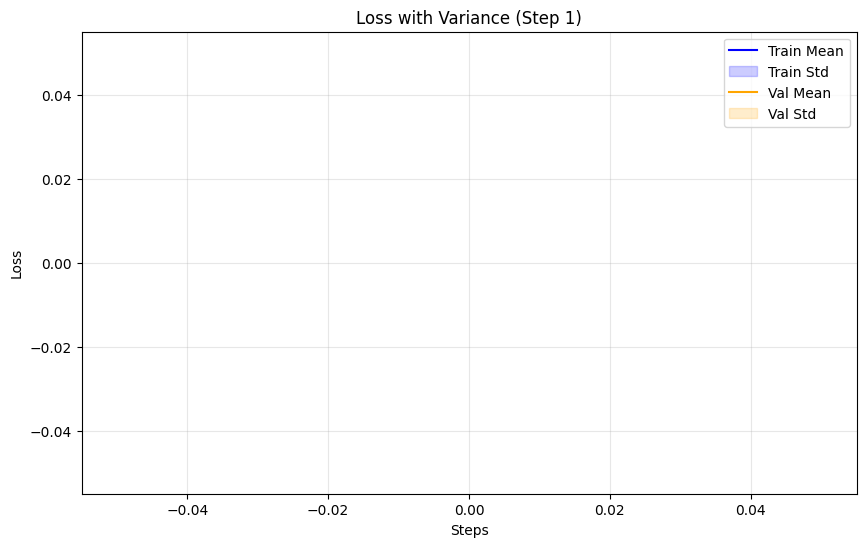

In [10]:
steps = np.array(step_history)
t_mean = np.array(train_history['mean'])
t_std  = np.array(train_history['std'])
v_mean = np.array(val_history['mean'])
v_std  = np.array(val_history['std'])

plt.figure(figsize=(10, 6))

plt.plot(steps, t_mean, label='Train Mean', color='blue')
plt.fill_between(steps, t_mean - t_std, t_mean + t_std, color='blue', alpha=0.2, label='Train Std')

# Plot Validation
plt.plot(steps, v_mean, label='Val Mean', color='orange')
plt.fill_between(steps, v_mean - v_std, v_mean + v_std, color='orange', alpha=0.2, label='Val Std')

plt.title(f'Loss with Variance (Step {epoch})')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
checkpoint = {
    'model': model.state_dict(),
    'optimizer': optim.state_dict(),
}
torch.save(checkpoint, 'one_layer_transformer.pth')

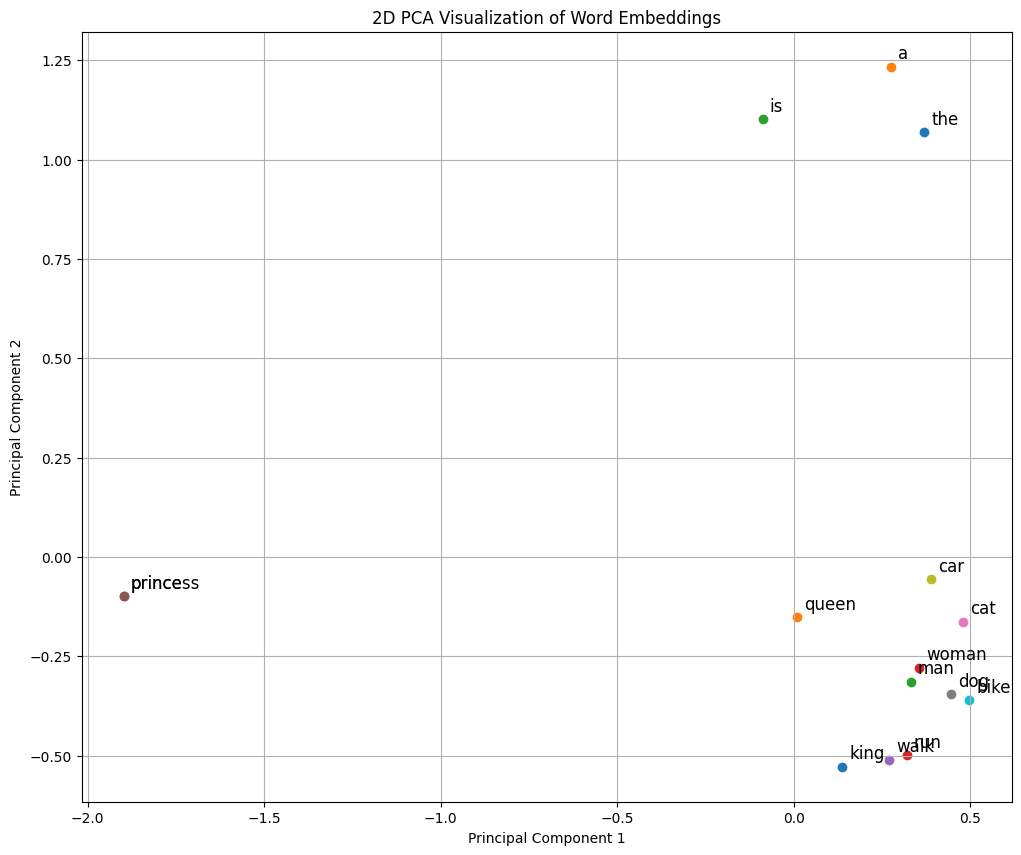

In [12]:
embeddings = model.W_E.weight.detach().cpu().numpy()
vocab_size, d_model = embeddings.shape

all_tokens = [enc.decode([i]) for i in range(vocab_size)]

words_to_track = ["king", "queen", "man", "woman", "prince", "princess", 
                  "cat", "dog", "car", "bike", "the", "a", "is", "run", "walk"]

indices_to_track = [enc.encode(word)[0] for word in words_to_track]

embeddings_subset = embeddings[indices_to_track]

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_subset)

plt.figure(figsize=(12, 10))

for i, word in enumerate(words_to_track):
    x, y = embeddings_2d[i, 0], embeddings_2d[i, 1]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=12)

plt.title("2D PCA Visualization of Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


In [13]:
def sample_from_model(model, start_text, encoder, max_new_tokens, temperature=1.0, top_k=50):
    model.eval()
    model.to(device)

    start_tokens = encoder.encode(start_text)
    idx = torch.tensor(start_tokens, dtype=torch.long, device=device)
    if idx.dim() == 1:
        idx = idx.unsqueeze(0) 

    for _ in range(max_new_tokens):
        logits = model(idx)
        logits = logits[:, -1, :] 
        
        if temperature != 0:
            logits = logits / temperature

        if top_k is not None:
            top_logits, top_idx = torch.topk(logits, top_k, dim=-1)
            logits_filtered = torch.full_like(logits, float('-inf'))
            logits_filtered.scatter_(1, top_idx, top_logits)
            logits = logits_filtered

        probs = F.softmax(logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1)
        
        idx = torch.cat((idx, next_idx), dim=1)
        
    generated_tokens = idx.squeeze(0).cpu().numpy()
    return encoder.decode(generated_tokens)

In [14]:
# """3 + 4 = 7, 2 + 6 = 8, 1 + 3 = 4, 4 + 2 = 6, 2 + 0 = 2, 1 + 2 = 3, 1 + 1 = 2, 4 + 4 = 8, 1 + 3 = 4, 4 + 1 = 5, 7 + 2 = 9, 2 + 3 = 5, 6 + 2 = 8,  4 + 5 = """
start_prompt = """First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved."""
generated_text = sample_from_model(
    model=model,
    start_text=start_prompt,
    encoder=enc,
    max_new_tokens=100,
    temperature=1,
    top_k=100
)

print("\n--- Generated Text ---")
print(generated_text)


--- Generated Text ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

At that time, what? I am entitled to have changed my name?

You know, I hope I get to see her again. And, my life in Afghanistan is now being destroyed.

No, no? I knew the entire world, including Afghanistan, Afghanistan, Indonesia.

I wanted to present an honest silence, my voice rising back. She� Now























In [15]:
def test_prompt(model, start_text, encoder, test_sample, temperature=1):
    model.eval()
    model.to(device)

    start_tokens = encoder.encode(start_text)
    idx = torch.tensor(start_tokens, dtype=torch.long, device=device)
    if idx.dim() == 1:
        idx = idx.unsqueeze(0) 

    logits = model(idx)
    logits = logits[0, -1, :] 
    
    if temperature != 0:
        logits = logits / temperature

    probs = F.softmax(logits, dim=-1)
    p = probs.reshape(-1).cpu()
    v = logits.reshape(-1).cpu()

    sorted_values, original_indices = torch.sort(p, descending=True)
        
    scaled_values = sorted_values * 100
    formatted_values = [f"{val:.3f}" for val in scaled_values]
    decoded_test_token = enc.encode(test_sample)[0]

    print(p[decoded_test_token])
    print("Token | Value (%)")
    print("---------------------")
    for i,(idx, val_str) in enumerate(zip(original_indices, formatted_values)):
        decoded_token = enc.decode([idx.item()])
        if i < 9:
            print(f"Top {i}th token. | Logits: {v[idx].item():.3f},  Probs: {val_str:<3}% | Token: {decoded_token:<20}")
        if idx == decoded_test_token:
            print(f"Top {i}th token. | Logits: {v[idx].item():.3f},  Probs: {val_str:<3}% | Token: {decoded_token:<20}")

    return probs, logits

In [16]:
probs, values = test_prompt(model, """Mr Dursley was privet driver. 
Mr Dursley was the director of a firm.
Mr Dursley was thin and blonde and had nearly twice the usual amount of neck.
Mr Dursley had a small son called Dudley. 
Mr""", enc, ' Dursley')

tensor(0.4304, grad_fn=<SelectBackward0>)
Token | Value (%)
---------------------
Top 0th token. | Logits: 12.856,  Probs: 43.039% | Token:  D                  
Top 0th token. | Logits: 12.856,  Probs: 43.039% | Token:  D                  
Top 1th token. | Logits: 9.495,  Probs: 1.494% | Token:  Mr                 
Top 2th token. | Logits: 8.934,  Probs: 0.853% | Token:  B                  
Top 3th token. | Logits: 8.714,  Probs: 0.684% | Token:  McG                
Top 4th token. | Logits: 8.705,  Probs: 0.678% | Token:  Th                 
Top 5th token. | Logits: 8.586,  Probs: 0.602% | Token:  Kenny              
Top 6th token. | Logits: 8.559,  Probs: 0.586% | Token:  F                  
Top 7th token. | Logits: 8.535,  Probs: 0.572% | Token:  Doyle              
Top 8th token. | Logits: 8.451,  Probs: 0.526% | Token:  Stevens            


In [17]:
probs, values = test_prompt(model, """the life A B X F is perfect but Fruits are whatever A B X""", enc, ' F')

tensor(0.2313, grad_fn=<SelectBackward0>)
Token | Value (%)
---------------------
Top 0th token. | Logits: 10.724,  Probs: 23.127% | Token:  F                  
Top 0th token. | Logits: 10.724,  Probs: 23.127% | Token:  F                  
Top 1th token. | Logits: 10.622,  Probs: 20.888% | Token:  is                 
Top 2th token. | Logits: 8.088,  Probs: 1.657% | Token:  can                
Top 3th token. | Logits: 8.062,  Probs: 1.614% | Token:  C                  
Top 4th token. | Logits: 7.873,  Probs: 1.337% | Token: F                   
Top 5th token. | Logits: 7.868,  Probs: 1.330% | Token:  or                 
Top 6th token. | Logits: 7.848,  Probs: 1.303% | Token:  has                
Top 7th token. | Logits: 7.601,  Probs: 1.018% | Token: -                   
Top 8th token. | Logits: 7.596,  Probs: 1.013% | Token:  f                  


In [18]:
probs, values = test_prompt(model, """AAB BBC CCD DDE EEF FFG GGH HHI IIJ JJK KKL LLM MMN NNO""", enc, ' O')

tensor(0.0022, grad_fn=<SelectBackward0>)
Token | Value (%)
---------------------
Top 0th token. | Logits: 10.689,  Probs: 14.215% | Token: X                   
Top 1th token. | Logits: 8.772,  Probs: 2.090% | Token: A                   
Top 2th token. | Logits: 8.748,  Probs: 2.042% | Token: AM                  
Top 3th token. | Logits: 8.713,  Probs: 1.970% | Token: AA                  
Top 4th token. | Logits: 8.636,  Probs: 1.825% | Token:  E                  
Top 5th token. | Logits: 8.266,  Probs: 1.260% | Token:  A                  
Top 6th token. | Logits: 8.179,  Probs: 1.155% | Token: Z                   
Top 7th token. | Logits: 8.117,  Probs: 1.086% | Token:  W                  
Top 8th token. | Logits: 7.998,  Probs: 0.964% | Token:  D                  
Top 63th token. | Logits: 6.510,  Probs: 0.218% | Token:  O                  


In [19]:
probs, values = test_prompt(model, """1 2 3 4 5 6 7""", enc, ' 8')

tensor(0.1812, grad_fn=<SelectBackward0>)
Token | Value (%)
---------------------
Top 0th token. | Logits: 11.620,  Probs: 18.123% | Token:  8                  
Top 0th token. | Logits: 11.620,  Probs: 18.123% | Token:  8                  
Top 1th token. | Logits: 11.279,  Probs: 12.889% | Token:  7                  
Top 2th token. | Logits: 11.039,  Probs: 10.139% | Token:  9                  
Top 3th token. | Logits: 10.117,  Probs: 4.032% | Token: .                   
Top 4th token. | Logits: 9.870,  Probs: 3.150% | Token:  1                  
Top 5th token. | Logits: 9.837,  Probs: 3.048% | Token:  2                  
Top 6th token. | Logits: 9.637,  Probs: 2.495% | Token:  6                  
Top 7th token. | Logits: 9.528,  Probs: 2.238% | Token: ,                   
Top 8th token. | Logits: 9.507,  Probs: 2.191% | Token:  5                  


In [20]:
probs, values = test_prompt(model, """00 10 20 30 40 50 60 70 80 90 01 11 21 31 41 51 61 71 81 91 02 12 22 32 42 52 62 72 82 92 03 13 23 33 43 53 63 73 83""", enc, ' 93')

tensor(0.0038, grad_fn=<SelectBackward0>)
Token | Value (%)
---------------------
Top 0th token. | Logits: 9.980,  Probs: 3.193% | Token:  87                 
Top 1th token. | Logits: 9.856,  Probs: 2.818% | Token:  0                  
Top 2th token. | Logits: 9.587,  Probs: 2.155% | Token:  89                 
Top 3th token. | Logits: 9.583,  Probs: 2.145% | Token: 01                  
Top 4th token. | Logits: 9.476,  Probs: 1.928% | Token:  1                  
Top 5th token. | Logits: 9.305,  Probs: 1.625% | Token:  7                  
Top 6th token. | Logits: 9.133,  Probs: 1.368% | Token: -                   
Top 7th token. | Logits: 9.128,  Probs: 1.361% | Token:  83                 
Top 8th token. | Logits: 9.086,  Probs: 1.306% | Token:  8                  
Top 61th token. | Logits: 7.844,  Probs: 0.377% | Token:  93                 



--- Skip-Trigram Analysis (Layer 5, Head 0) ---
Checking factorization for: [' A', 'B', ' C', ' D', ' X', ' F', ' E', ' A', ' B', ' C', ' D', ' X', ' F', ' E', ' A', ' B', ' C', ' D', ' X', ' F', ' E']


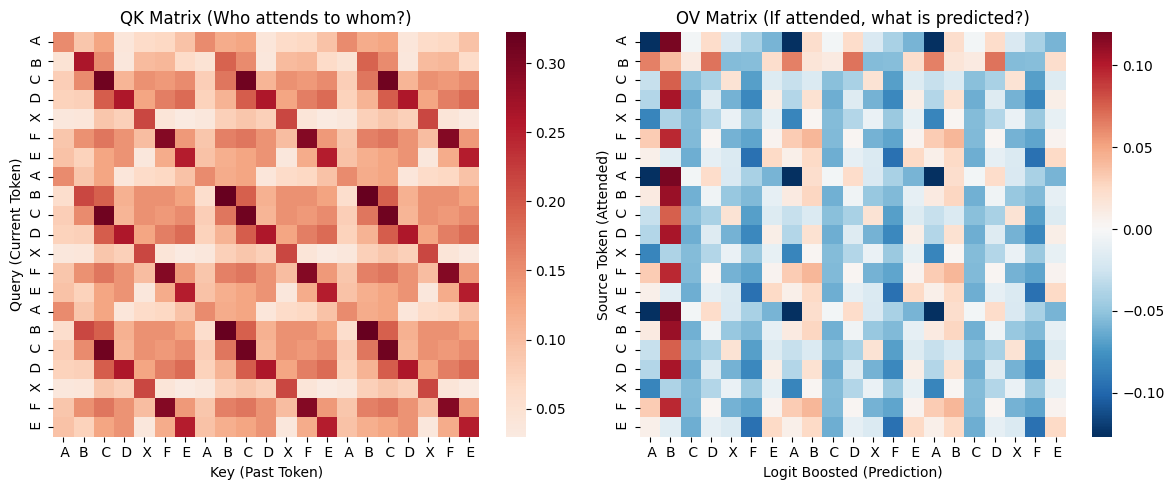

INTERPRETATION:
1. Look at QK: If 'in' or 'at' (Query) attends strongly to 'keep' (Key).
2. Look at OV: If 'keep' (Source) boosts BOTH 'mind' and 'bay' (Prediction).
3. THE BUG: If both are true, the model boosts 'keep at mind' and 'keep in bay'.
   It cannot conditionally boost 'mind' only if the query was 'in'.


In [ ]:

def analyze_skip_trigram_bugs(model, layer_idx, head_idx):
    """
    Visualizes the QK (Attention) and OV (Output) matrices for a specific head
    on a small subset of words to demonstrate the 'factorization bug'.
    """
    device = next(model.parameters()).device
    
    # 1. Define the 'Bug' Vocabulary
    # Scenario: "Keep in mind" vs "Keep at bay".
    # The model should not predict "Keep at mind" or "Keep in bay".
    words = [' A', 'B', ' C', ' D', ' X', ' F', ' E', ' A', ' B', ' C', ' D', ' X', ' F', ' E', ' A', ' B', ' C', ' D', ' X', ' F', ' E'] # [' A', 'B', ' C', ' D', ' X', ' F', ' E', ' A', ' B', ' C', 'D', 'X', 'F', 'E', 'A', 'B', 'C', 'D', 'X', 'F', 'E']
    token_ids = [enc.encode(w)[0] for w in words]
    vocab_subset_size = len(token_ids)
    
    print(f"\n--- Skip-Trigram Analysis (Layer {layer_idx}, Head {head_idx}) ---")
    print(f"Checking factorization for: {words}")

    with torch.no_grad():
        # 2. Extract Weights for this specific Head
        # W_E: [Vocab, d_model]
        E = model.W_E.weight[token_ids, :] # Subset embedding [5, d_model]
        U = model.W_U.weight[token_ids, :] # Subset unembedding [5, d_model] (Target logits)

        # Slicing the Head weights
        # Note: Your model stores weights as [Out, In] or [In, Out] depending on Linear definition.
        # PyTorch Linear weights are [Out_Features, In_Features].
        
        # W_Q: [n_heads*d_head, d_model] -> slice to [d_head, d_model]
        W_Q_all = model.W_Q[layer_idx].weight
        W_K_all = model.W_K[layer_idx].weight
        W_V_all = model.W_V[layer_idx].weight
        W_O_all = model.W_O[layer_idx].weight

        d_head = model.d_head
        start = head_idx * d_head
        end = (head_idx + 1) * d_head
        
        # Extract specific head weights
        W_Q = W_Q_all[start:end, :]   # [d_head, d_model]
        W_K = W_K_all[start:end, :]   # [d_head, d_model]
        W_V = W_V_all[start:end, :]   # [d_head, d_model]
        W_O = W_O_all[:, start:end]   # [d_model, d_head] (W_O is usually projected back)

        # 3. Calculate QK Circuit (Who attends to whom?)
        # Score = (E_query @ W_Q.T) @ (E_key @ W_K.T).T
        # But simpler: Full QK Matrix in Embedding space = W_Q.T @ W_K
        # We want the interactions between our specific tokens.
        
        # Q_subset = E @ W_Q.T  (Query vectors for our 5 words)
        # K_subset = E @ W_K.T  (Key vectors for our 5 words)
        Q_subset = torch.matmul(E, W_Q.T)
        K_subset = torch.matmul(E, W_K.T)
        
        # Attention Scores (Unnormalized logits)
        # Shape: [5, 5] (Row: Query/Current, Col: Key/Previous)
        QK_matrix = torch.matmul(Q_subset, K_subset.T) / (d_head ** 0.5)

        # 4. Calculate OV Circuit (Who predicts whom?)
        # Effect = (E_source @ W_V.T @ W_O.T) @ U.T
        # Meaning: If I attend to 'source', what logits do I increase?
        
        V_subset = torch.matmul(E, W_V.T) # [5, d_head]
        Out_subset = torch.matmul(V_subset, W_O.T) # [5, d_model]
        OV_matrix = torch.matmul(Out_subset, U.T) # [5, 5] (Row: Attended Token, Col: Logit Boosted)

    # 5. Visualization
    plt.figure(figsize=(12, 5))
    
    # Plot QK (Attention)
    plt.subplot(1, 2, 1)
    sns.heatmap(QK_matrix.cpu().numpy(), xticklabels=words, yticklabels=words, cmap="RdBu_r", center=0)
    plt.title("QK Matrix (Who attends to whom?)")
    plt.xlabel("Key (Past Token)")
    plt.ylabel("Query (Current Token)")
    
    # Plot OV (Prediction)
    plt.subplot(1, 2, 2)
    sns.heatmap(OV_matrix.cpu().numpy(), xticklabels=words, yticklabels=words, cmap="RdBu_r", center=0)
    plt.title("OV Matrix (If attended, what is predicted?)")
    plt.xlabel("Logit Boosted (Prediction)")
    plt.ylabel("Source Token (Attended)")
    
    plt.tight_layout()
    plt.show()
 
# Run it on a likely induction head (e.g., Layer 5, Head 0 from previous assumptions)
analyze_skip_trigram_bugs(model, layer_idx=5, head_idx=0)

Computing Eigenvalues for visualization...


/var/folders/rf/h04h57cj31b591rd_k2072b00000gn/T/ipykernel_59363/1788111260.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


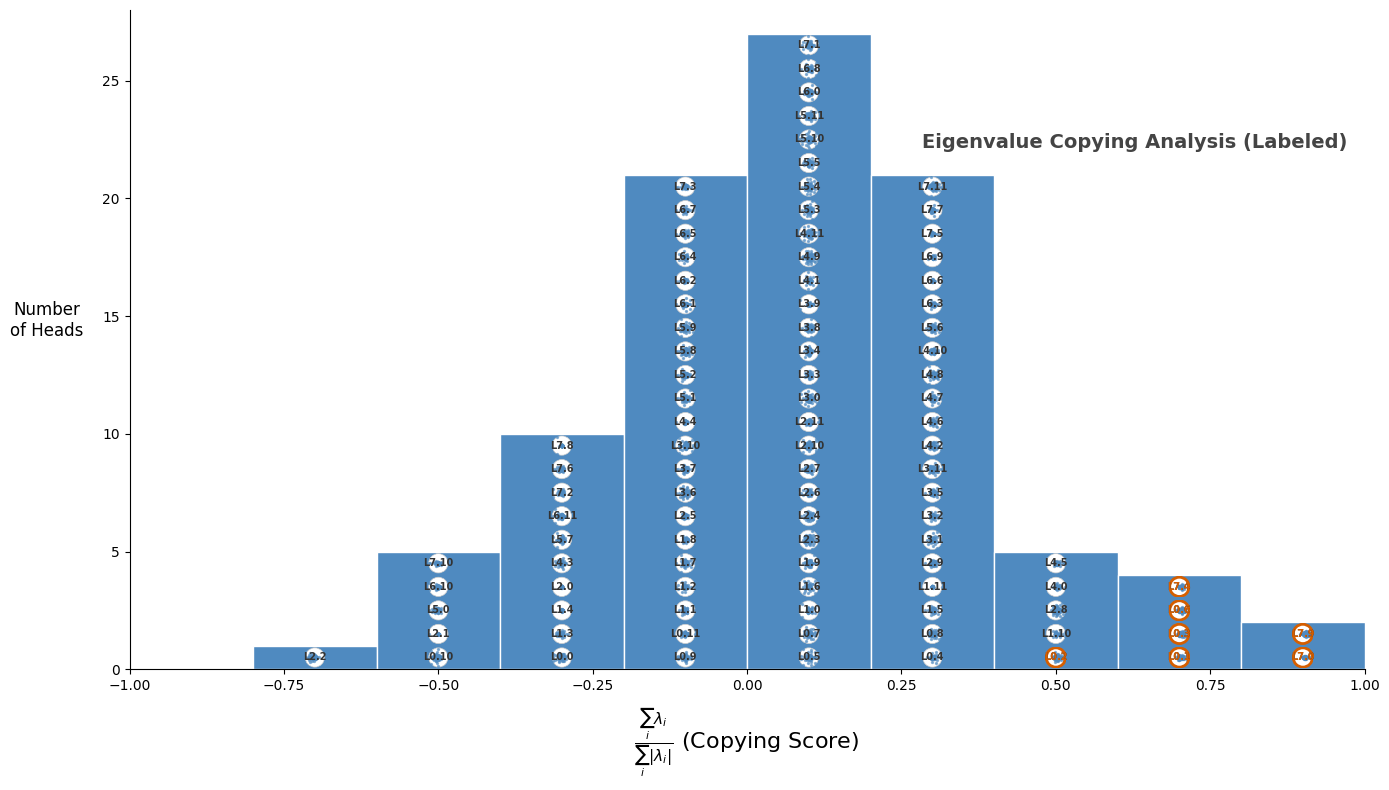

In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def get_eigenvalue_data(model):
    """
    Computes eigenvalues for every head and calculates the 'Copying Ratio'.
    Returns a list of dictionaries containing the raw eigenvalues and the score.
    """
    device = next(model.parameters()).device
    heads_data = []

    print("Computing Eigenvalues for visualization...")
    
    with torch.no_grad():
        W_E = model.W_E.weight 
        W_U = model.W_U.weight
        
        for l in range(model.num_layers):
            W_V_all = model.W_V[l].weight 
            W_O_all = model.W_O[l].weight
            
            for h in range(model.n_heads):
                # 1. Slice Weights
                d_head = model.d_head
                start = h * d_head
                end = (h + 1) * d_head
                
                W_V = W_V_all[start:end, :] 
                W_O = W_O_all[:, start:end]
                
                # 2. Compute the OV Circuit matrix S = (W_O^T W_U^T) (W_E W_V^T)
                # (Transposed math to match dimensions)
                A = torch.matmul(W_E, W_V.T)      # [Vocab, d_head]
                B = torch.matmul(W_O.T, W_U.T)    # [d_head, Vocab]
                
                S = torch.matmul(B, A)            # [d_head, d_head]
                
                # 3. Move to CPU for Eigendecomposition (Fixes MPS issue)
                S_cpu = S.float().cpu()
                evals = torch.linalg.eigvals(S_cpu) # Complex eigenvalues
                
                # 4. Calculate the Metric from the Anthropic paper
                # Score = Sum(Re(lambda)) / Sum(|lambda|)
                numerator = evals.real.sum()
                denominator = evals.abs().sum()
                
                # Avoid div by zero
                if denominator < 1e-9:
                    score = 0.0
                else:
                    score = (numerator / denominator).item()
                
                heads_data.append({
                    "layer": l,
                    "head": h,
                    "score": score,
                    "evals": evals.numpy() # Store for plotting
                })
    
    return heads_data

def plot_anthropic_histogram_with_labels(heads_data):
    """
    Recreates the 'Histograms of attention heads' figure with Layer.Head labels.
    """
    scores = [d['score'] for d in heads_data]
    
    # Setup Figure
    fig, ax = plt.subplots(figsize=(14, 8)) # Made slightly wider to accommodate labels
    
    # 1. Define Bins
    bins = np.linspace(-1.0, 1.0, 11) # 10 bins
    bin_width = bins[1] - bins[0]
    
    # 2. Assign heads to bins and calculate stacking positions
    bin_counts = np.zeros(len(bins)-1, dtype=int)
    head_positions = []
    
    for data in heads_data:
        s = data['score']
        # Find bin index
        bin_idx = np.digitize(s, bins) - 1
        bin_idx = min(max(bin_idx, 0), len(bins)-2)
        
        # Calculate positions
        x_pos = (bins[bin_idx] + bins[bin_idx+1]) / 2
        y_pos = bin_counts[bin_idx]
        
        bin_counts[bin_idx] += 1
        
        # Store data needed for plotting
        head_positions.append({
            "x": x_pos,
            "y": y_pos, 
            "evals": data['evals'],
            "score": s,
            "layer": data['layer'], # Passing Layer
            "head": data['head']    # Passing Head
        })

    # 3. Draw the main blue bars
    ax.bar(bins[:-1], bin_counts, width=bin_width, align='edge', 
           color='#4F8AC0', edgecolor='white', alpha=1.0)

    # 4. Draw the Eigenvalue Circles (Inset Axes)
    circle_width = bin_width * 0.95 
    max_y = max(bin_counts) if len(bin_counts) > 0 else 1
    
    for item in head_positions:
        x, y = item['x'], item['y']
        evals = item['evals']
        layer_idx = item['layer']
        head_idx = item['head']
        
        # Normalize eigenvalues
        max_abs = np.max(np.abs(evals))
        if max_abs > 0:
            norm_evals = evals / max_abs
        else:
            norm_evals = evals

        # Create inset axis
        ax_ins = inset_axes(ax, width="100%", height="100%", 
                            bbox_to_anchor=(x - circle_width/2, y + 0.05, circle_width, 0.9), 
                            bbox_transform=ax.transData, loc='lower left', borderpad=0)
        
        ax_ins.set_axis_off()
        ax_ins.set_aspect('equal')
        ax_ins.set_xlim(-1.1, 1.1)
        ax_ins.set_ylim(-1.1, 1.1)
        
        # Draw background circle
        circle = Circle((0, 0), 1.0, facecolor='white', edgecolor='#CCCCCC', lw=0.5)
        ax_ins.add_patch(circle)
        
        # Draw Scatter Plot
        ax_ins.scatter(norm_evals.real, norm_evals.imag, 
                       s=2, c='#4F8AC0', alpha=0.6) # Slightly transparent to see text
        
        # Draw Label: "L{layer}.{head}"
        label_text = f"L{layer_idx}.{head_idx}"
        ax_ins.text(0, 0, label_text, ha='center', va='center', 
                    fontsize=7, fontweight='bold', color='#333333')
        
        # Highlight Copying Heads (Score > 0.5)
        if item['score'] > 0.5:
            # Red outline
            circle_edge = Circle((0, 0), 1.0, facecolor='none', edgecolor='#D55E00', lw=2.0, alpha=1.0)
            ax_ins.add_patch(circle_edge)
            
            # Change text color to match the "alert" style of the outline
            ax_ins.text(0, 0, label_text, ha='center', va='center', 
                        fontsize=7, fontweight='bold', color='#D55E00')

    # 5. Final Formatting
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(0, max_y + 1)
    
    ax.set_xlabel(r"$\frac{\sum_i \lambda_i}{\sum_i |\lambda_i|}$ (Copying Score)", fontsize=16, labelpad=10)
    ax.set_ylabel("Number\nof Heads", rotation=0, labelpad=40, fontsize=12)
    
    plt.title("Eigenvalue Copying Analysis (Labeled)", loc='left', fontsize=14, pad=20, fontweight='bold', color='#444444')
    
    # Hide top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# --- RUN IT ---
# Assuming 'model' is your loaded 8-layer transformer
data = get_eigenvalue_data(model)
plot_anthropic_histogram_with_labels(data)

In [23]:
input_text = """A B C D E A B C D E A B C D E A B C D """

tokens = enc.encode(input_text)
input_tensor = torch.tensor(tokens).unsqueeze(0)
input_tensor= input_tensor.to(device)

model.eval()
model.to(device)
with torch.no_grad():
    logits, cache = model(input_tensor, return_all=True)


W_QK shape (Layer 0): torch.Size([12, 768, 768])
W_OV shape (Layer 0): torch.Size([12, 768, 768])

Selected: Layer 0, Head 0
W_QK_head shape: torch.Size([768, 768])
W_OV_head shape: torch.Size([768, 768])


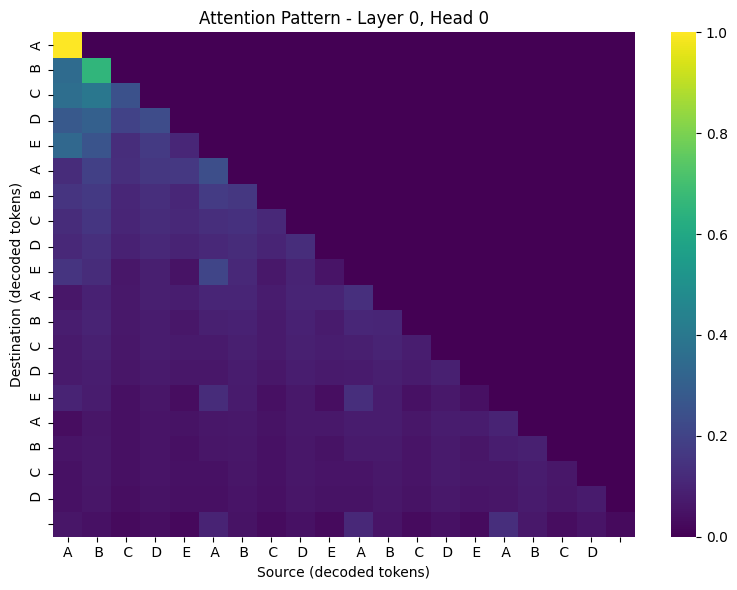

/var/folders/rf/h04h57cj31b591rd_k2072b00000gn/T/ipykernel_59363/2528503897.py:154: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  _, S, _ = torch.svd(matrix)


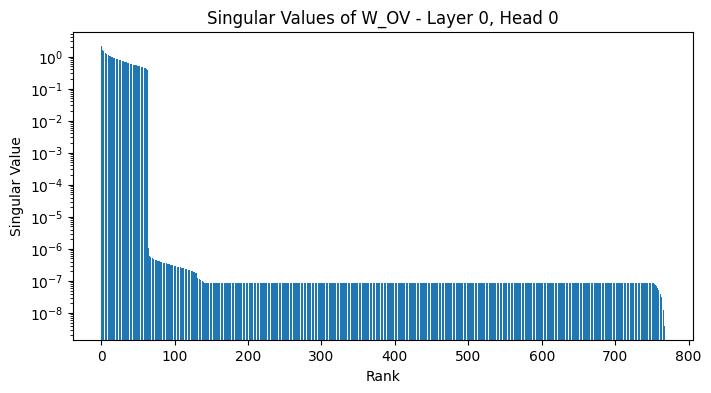


Layer 0, Head 0 strongest direction boosts tokens:
  1. ued (logit: 0.252)
  2. nce (logit: 0.244)
  3. sing (logit: 0.241)
  4. sky (logit: 0.232)
  5. sed (logit: 0.226)
  6. sburgh (logit: 0.222)
  7. nd (logit: 0.212)
  8. ly (logit: 0.205)
  9. ér (logit: 0.204)
  10.  dots (logit: 0.203)


In [24]:

# ==================== CORRECTED EXTRACTION FUNCTIONS ====================

def extract_W_QK(model, layer_idx=None):
    """
    Extract W_QK circuit for attention patterns.
    
    Args:
        model: Transformer model
        layer_idx: If None, returns all layers. If int, returns that layer only.
                   Returns shape [num_layers, n_heads, d_model, d_model] or [n_heads, d_model, d_model]
    
    Returns:
        W_QK: [num_layers, n_heads, d_model, d_model] or [n_heads, d_model, d_model]
    """
    n_heads = model.n_heads
    d_head = model.d_head
    d_model = model.d_model
    num_layers = model.num_layers
    
    # Determine which layers to extract
    if layer_idx is not None:
        layer_indices = [layer_idx]
    else:
        layer_indices = range(num_layers)
    
    all_W_QK = []
    
    for l in layer_indices:
        # W_Q[l].weight: [n_heads * d_head, d_model] -> reshape to [n_heads, d_head, d_model]
        W_Q = model.W_Q[l].weight.view(n_heads, d_head, d_model)
        W_K = model.W_K[l].weight.view(n_heads, d_head, d_model)
        
        # Compute W_QK per head: [n_heads, d_model, d_head] @ [n_heads, d_head, d_model]
        # Result: [n_heads, d_model, d_model]
        W_QK = torch.bmm(W_Q.transpose(1, 2), W_K)  # [n_heads, d_model, d_model]
        all_W_QK.append(W_QK)
    
    if layer_idx is not None:
        return all_W_QK[0]  # [n_heads, d_model, d_model]
    else:
        return torch.stack(all_W_QK, dim=0)  # [num_layers, n_heads, d_model, d_model]


def extract_W_OV(model, layer_idx=None):
    """
    Extract W_OV circuit (output-value composition).
    
    Args:
        model: Transformer model
        layer_idx: If None, returns all layers. If int, returns that layer only.
                   Returns shape [num_layers, n_heads, d_model, d_model] or [n_heads, d_model, d_model]
    
    Returns:
        W_OV: [num_layers, n_heads, d_model, d_model] or [n_heads, d_model, d_model]
              where W_OV[l, h] = W_O[l, h] @ W_V[l, h]
    """
    n_heads = model.n_heads
    d_head = model.d_head
    d_model = model.d_model
    num_layers = model.num_layers
    
    # Determine which layers to extract
    if layer_idx is not None:
        layer_indices = [layer_idx]
    else:
        layer_indices = range(num_layers)
    
    all_W_OV = []
    
    for l in layer_indices:
        # W_V[l].weight: [n_heads * d_head, d_model] -> reshape to [n_heads, d_head, d_model]
        W_V = model.W_V[l].weight.view(n_heads, d_head, d_model)
        
        # W_O[l].weight: [d_model, n_heads * d_head] -> reshape to [d_model, n_heads, d_head]
        W_O = model.W_O[l].weight.view(d_model, n_heads, d_head)
        
        # Permute W_O to [n_heads, d_model, d_head]
        W_O = W_O.permute(1, 0, 2)
        
        # Batch matmul: [n_heads, d_model, d_head] @ [n_heads, d_head, d_model]
        # Result: [n_heads, d_model, d_model]
        W_OV = torch.bmm(W_O, W_V)
        all_W_OV.append(W_OV)
    
    if layer_idx is not None:
        return all_W_OV[0]  # [n_heads, d_model, d_model]
    else:
        return torch.stack(all_W_OV, dim=0)  # [num_layers, n_heads, d_model, d_model]

# ==================== VISUALIZATION FUNCTIONS ====================

def visualize_attention_pattern(pattern, head=0, title="Attention Pattern", tokens=None, enc=None):
    """
    pattern: attention pattern tensor [batch, n_heads, seq_len, seq_len]
    head: which head to visualize
    tokens: list or tensor of token ids for axis labels (optional)
    enc: tokenizer with .decode, to decode tokens (optional)
    """
    pat = pattern[0, head].detach().cpu().numpy()  # [T, T]
    seq_len = pat.shape[0]
    
    plt.figure(figsize=(8, 6))
    
    # Prepare axis labels
    if tokens is not None and enc is not None:
        # Ensure tokens match sequence length
        if isinstance(tokens, torch.Tensor):
            tokens = tokens.cpu().numpy().tolist()
        elif isinstance(tokens, list):
            tokens = [int(t) if isinstance(t, (torch.Tensor, np.integer)) else t for t in tokens]
        
        # Truncate or handle length mismatch
        if len(tokens) != seq_len:
            if len(tokens) > seq_len:
                tokens = tokens[:seq_len]
            else:
                # Pad with placeholder if needed (shouldn't happen, but handle gracefully)
                tokens = tokens + [0] * (seq_len - len(tokens))
        
        # Decode tokens safely
        try:
            xticklabels = []
            yticklabels = []
            for t in tokens:
                try:
                    decoded = enc.decode([int(t)])
                    # Replace problematic characters for display
                    decoded = decoded.replace('\n', '\\n').replace('\t', '\\t')
                    xticklabels.append(decoded)
                    yticklabels.append(decoded)
                except (ValueError, KeyError, IndexError):
                    # If decoding fails, show token ID
                    xticklabels.append(f"<{int(t)}>")
                    yticklabels.append(f"<{int(t)}>")
        except Exception as e:
            print(f"Warning: Token decoding failed: {e}. Using token IDs instead.")
            xticklabels = [str(int(t)) for t in tokens]
            yticklabels = [str(int(t)) for t in tokens]
        
        sns.heatmap(pat, cmap="viridis", xticklabels=xticklabels, yticklabels=yticklabels)
        plt.xlabel("Source (decoded tokens)")
        plt.ylabel("Destination (decoded tokens)")
    else:
        sns.heatmap(pat, cmap="viridis")
        plt.xlabel("Source")
        plt.ylabel("Destination")
    
    plt.title(title)
    plt.tight_layout()
    plt.show()


def visualize_svd(matrix, title="Singular Values"):
    _, S, _ = torch.svd(matrix)
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(S)), S.detach().cpu().numpy())
    plt.title(title)
    plt.xlabel("Rank")
    plt.ylabel("Singular Value")
    plt.yscale("log")
    plt.show()

def logit_lens(model, direction, enc, top_k=10):
    """
    Project a residual stream direction through unembedding to see boosted tokens.
    
    Args:
        model: Transformer model
        direction: Direction vector in embedding space [d_model]
        enc: Tokenizer/encoder with .decode method
        top_k: Number of top tokens to return
    
    Returns:
        top_idx: Top token indices
        top_vals: Top logit values
        top_tokens_decoded: Decoded token strings
    """
    logits = direction @ model.W_U.weight.T  # [vocab_size]
    top_vals, top_idx = torch.topk(logits, top_k)
    # decode the top tokens
    top_tokens_decoded = [enc.decode([i.item()]) for i in top_idx]
    return top_idx, top_vals, top_tokens_decoded

# ==================== MAIN EXAMPLE ====================

# ==================== CONFIGURATION VARIABLES ====================
# Easy-to-modify variables for selecting layers and heads
LAYER_IDX = 0  # Which layer to analyze (0-7 for 8-layer model)
HEAD_IDX = 0   # Which head to visualize (0-11 for 12-head model)
EXTRACT_ALL_LAYERS = False  # If True, extracts all layers; if False, only LAYER_IDX

# ==================== EXTRACT CIRCUITS ====================
# Extract circuits — now works with multi-layer support!
if EXTRACT_ALL_LAYERS:
    # Extract all layers: shape [num_layers, n_heads, d_model, d_model]
    W_QK_all = extract_W_QK(model, layer_idx=None)
    W_OV_all = extract_W_OV(model, layer_idx=None)
    print(f"W_QK_all shape: {W_QK_all.shape}")  # [8, 12, 768, 768]
    print(f"W_OV_all shape: {W_OV_all.shape}")  # [8, 12, 768, 768]
    
    # Select specific layer for analysis
    W_QK = W_QK_all[LAYER_IDX]  # [n_heads, d_model, d_model]
    W_OV = W_OV_all[LAYER_IDX]  # [n_heads, d_model, d_model]
else:
    # Extract only the specified layer: shape [n_heads, d_model, d_model]
    W_QK = extract_W_QK(model, layer_idx=LAYER_IDX)
    W_OV = extract_W_OV(model, layer_idx=LAYER_IDX)
    print(f"W_QK shape (Layer {LAYER_IDX}): {W_QK.shape}")  # [12, 768, 768]
    print(f"W_OV shape (Layer {LAYER_IDX}): {W_OV.shape}")  # [12, 768, 768]

# ==================== HELPER VARIABLES ====================
# Store individual head matrices for easier access
W_QK_head = W_QK[HEAD_IDX]  # [d_model, d_model] - QK matrix for selected head
W_OV_head = W_OV[HEAD_IDX]  # [d_model, d_model] - OV matrix for selected head

print(f"\nSelected: Layer {LAYER_IDX}, Head {HEAD_IDX}")
print(f"W_QK_head shape: {W_QK_head.shape}")
print(f"W_OV_head shape: {W_OV_head.shape}")

# ==================== FORWARD PASS DATA ====================
# Get cache if available
try:
    cache_available = cache is not None
except NameError:
    cache_available = False
    print("Warning: cache not available. Run forward pass with return_all=True first.")

# Get sequence tokens for axis labels - ensure they match the actual sequence length
seq_tokens = None
if cache_available and LAYER_IDX < len(cache['pattern']):
    # Get actual sequence length from cache
    actual_seq_len = cache['pattern'][LAYER_IDX].shape[-1]
    
    # Try to get tokens from local scope
    try:
        if "tokens" in locals() and tokens is not None:
            # Convert to list if needed
            if isinstance(tokens, torch.Tensor):
                tokens_list = tokens.cpu().numpy().tolist()
            elif isinstance(tokens, list):
                tokens_list = [int(t) if isinstance(t, (torch.Tensor, np.integer)) else int(t) for t in tokens]
            else:
                tokens_list = None
            
            if tokens_list is not None:
                # Ensure tokens match sequence length
                if len(tokens_list) == actual_seq_len:
                    seq_tokens = tokens_list
                elif len(tokens_list) > actual_seq_len:
                    seq_tokens = tokens_list[:actual_seq_len]
                    print(f"Info: Truncated tokens from {len(tokens_list)} to {actual_seq_len} to match sequence length")
                else:
                    print(f"Warning: Token list ({len(tokens_list)}) shorter than sequence length ({actual_seq_len}). Using indices.")
                    seq_tokens = None
    except Exception as e:
        print(f"Warning: Could not extract tokens: {e}")

# ==================== VISUALIZATIONS ====================
if cache_available and LAYER_IDX < len(cache['pattern']):
    # Visualize attention pattern from forward pass
    visualize_attention_pattern(
        cache['pattern'][LAYER_IDX], 
        head=HEAD_IDX, 
        title=f"Attention Pattern - Layer {LAYER_IDX}, Head {HEAD_IDX}", 
        tokens=seq_tokens, 
        enc=enc if "enc" in locals() else None,
    )
else:
    print("Skipping attention pattern visualization (cache not available)")


# ==================== SVD ANALYSIS ====================
# Analyze singular values of W_OV
visualize_svd(W_OV_head, f"Singular Values of W_OV - Layer {LAYER_IDX}, Head {HEAD_IDX}")

# ==================== LOGIT LENS ====================
# Logit lens on top OV direction
if "enc" in locals():
    U, S, Vh = torch.svd(W_OV_head)
    top_dir = U[:, 0]  # strongest write direction of selected head
    top_tokens, top_vals, top_tokens_decoded = logit_lens(model, top_dir, enc, top_k=10)
    print(f"\nLayer {LAYER_IDX}, Head {HEAD_IDX} strongest direction boosts tokens:")
    for i, (token, val) in enumerate(zip(top_tokens_decoded, top_vals)):
        print(f"  {i+1}. {token} (logit: {val.item():.3f})")
else:
    print("Skipping logit lens (encoder not available)")


In [25]:
def get_weighted_attnetion(cache, layer):
    v_norms = torch.norm(cache['v'][layer], p=2, dim=-1)
    v_norms_expanded = v_norms.unsqueeze(-2)
    weighted_contributions = cache['pattern'][layer] * v_norms_expanded
    return weighted_contributions

layer_1_weighted_contributions = get_weighted_attnetion(cache, 0)
layer_2_weighted_contributions = get_weighted_attnetion(cache, 1)
layer_6_weighted_contributions = get_weighted_attnetion(cache, 6)
layer_7_weighted_contributions = get_weighted_attnetion(cache, 7)

In [26]:
def plot_all_heads_next_token(attention_pattern, tokens, title='Layer Prediction Breakdown', figsize=(20, 12)):
    """
    Plots a grid of bar charts.
    Each subplot shows what a specific Head is looking at to predict the NEXT token.
    """
    # 1. Prepare Data
    # Get the last query position for ALL heads
    # Shape: [batch, heads, queries, keys] -> [heads, keys]
    if torch.is_tensor(attention_pattern):
        # Taking batch 0, all heads, last query (-1), all keys
        attn_data = attention_pattern[0, :, -1, :].detach().cpu().numpy()
    else:
        attn_data = attention_pattern[0, :, -1, :]

    num_heads = attn_data.shape[0]
    seq_len = attn_data.shape[1]

    # Ensure tokens match sequence length
    if len(tokens) > seq_len:
        tokens = tokens[:seq_len]
    
    # 2. Setup Grid
    rows = int(np.ceil(num_heads / 4))
    cols = min(num_heads, 4)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize, sharey=True)
    axes = axes.flatten() # Flattens the 2D grid into a 1D list for easy looping
    
    fig.suptitle(title, fontsize=20, y=1.02)
    decodeds = [enc.decode([i]) for i in tokens]

    # 3. Plot Loop
    for i in range(num_heads):
        ax = axes[i]
        scores = attn_data[i]
        
        # Draw Bars
        bars = ax.bar(range(len(scores)), scores, color='#a5b4fc', edgecolor='#4338ca')
        
        # Highlight the Winner (Max Attention)
        max_idx = np.argmax(scores)
        # if scores[max_idx] > 0.01: # Only highlight if there is actually attention
        bars[max_idx].set_color('#f59e0b') # Orange
        bars[max_idx].set_edgecolor('#b45309')
        bars[max_idx].set_linewidth(1.5)
            
            # Annotate the winner value
        ax.text(max_idx, scores[max_idx], f"{scores[max_idx]:.2f}", 
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color='#b45309')

        # Styling
        ax.set_title(f"Head {i}", fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # X-Axis Labels (The Tokens)
        # We rotate them 90 degrees so they fit
        ax.set_xticks(range(len(decodeds)))
        ax.set_xticklabels(decodeds, rotation=90, fontsize=8)
        
        # Only put Y label on the first column to reduce clutter
        if i % cols == 0:
            ax.set_ylabel("Attention / Impact")

    # Hide empty subplots if num_heads isn't a perfect multiple of 4
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

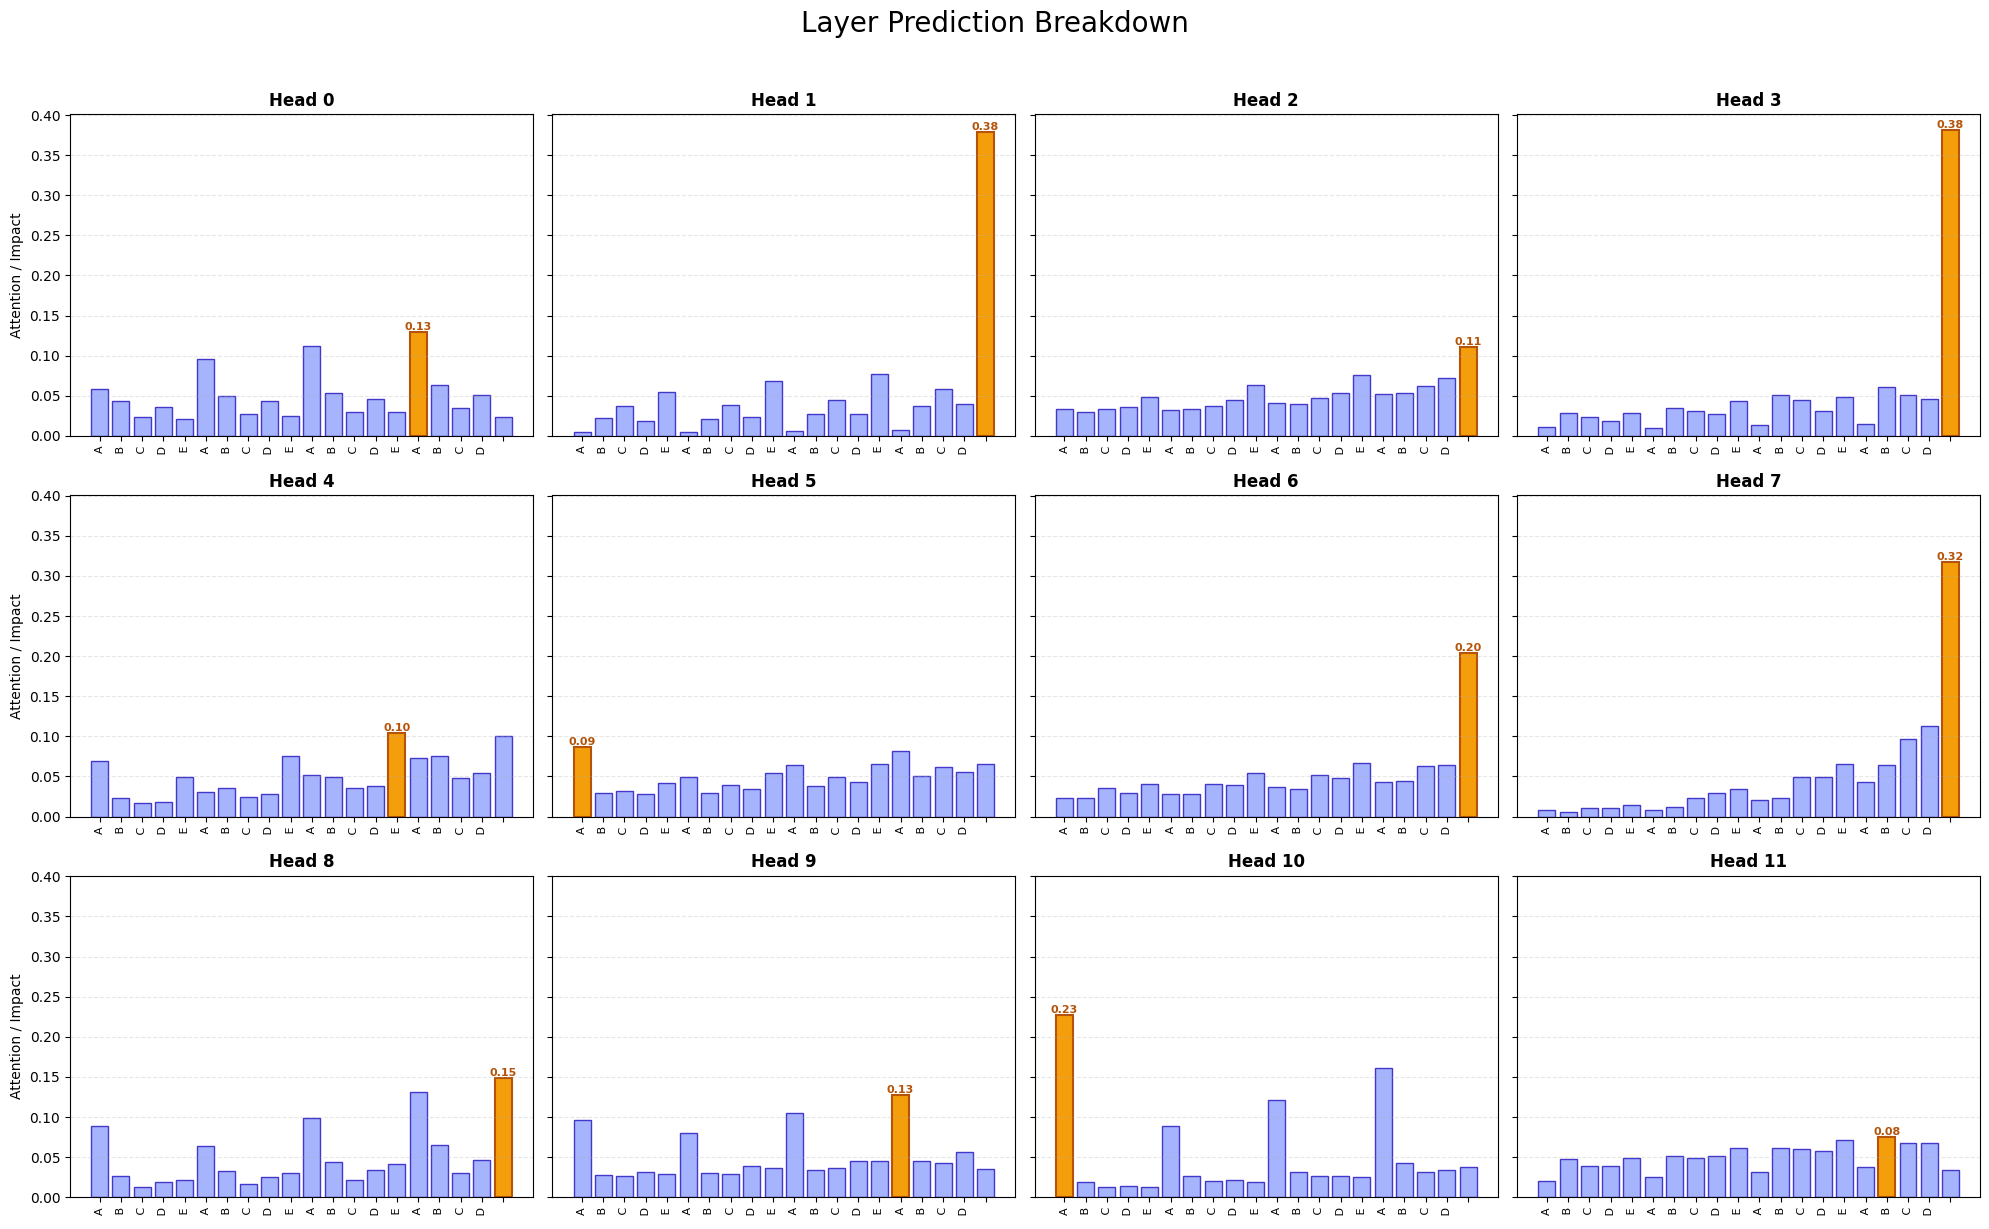

In [27]:
plot_all_heads_next_token(cache['pattern'][0], tokens)

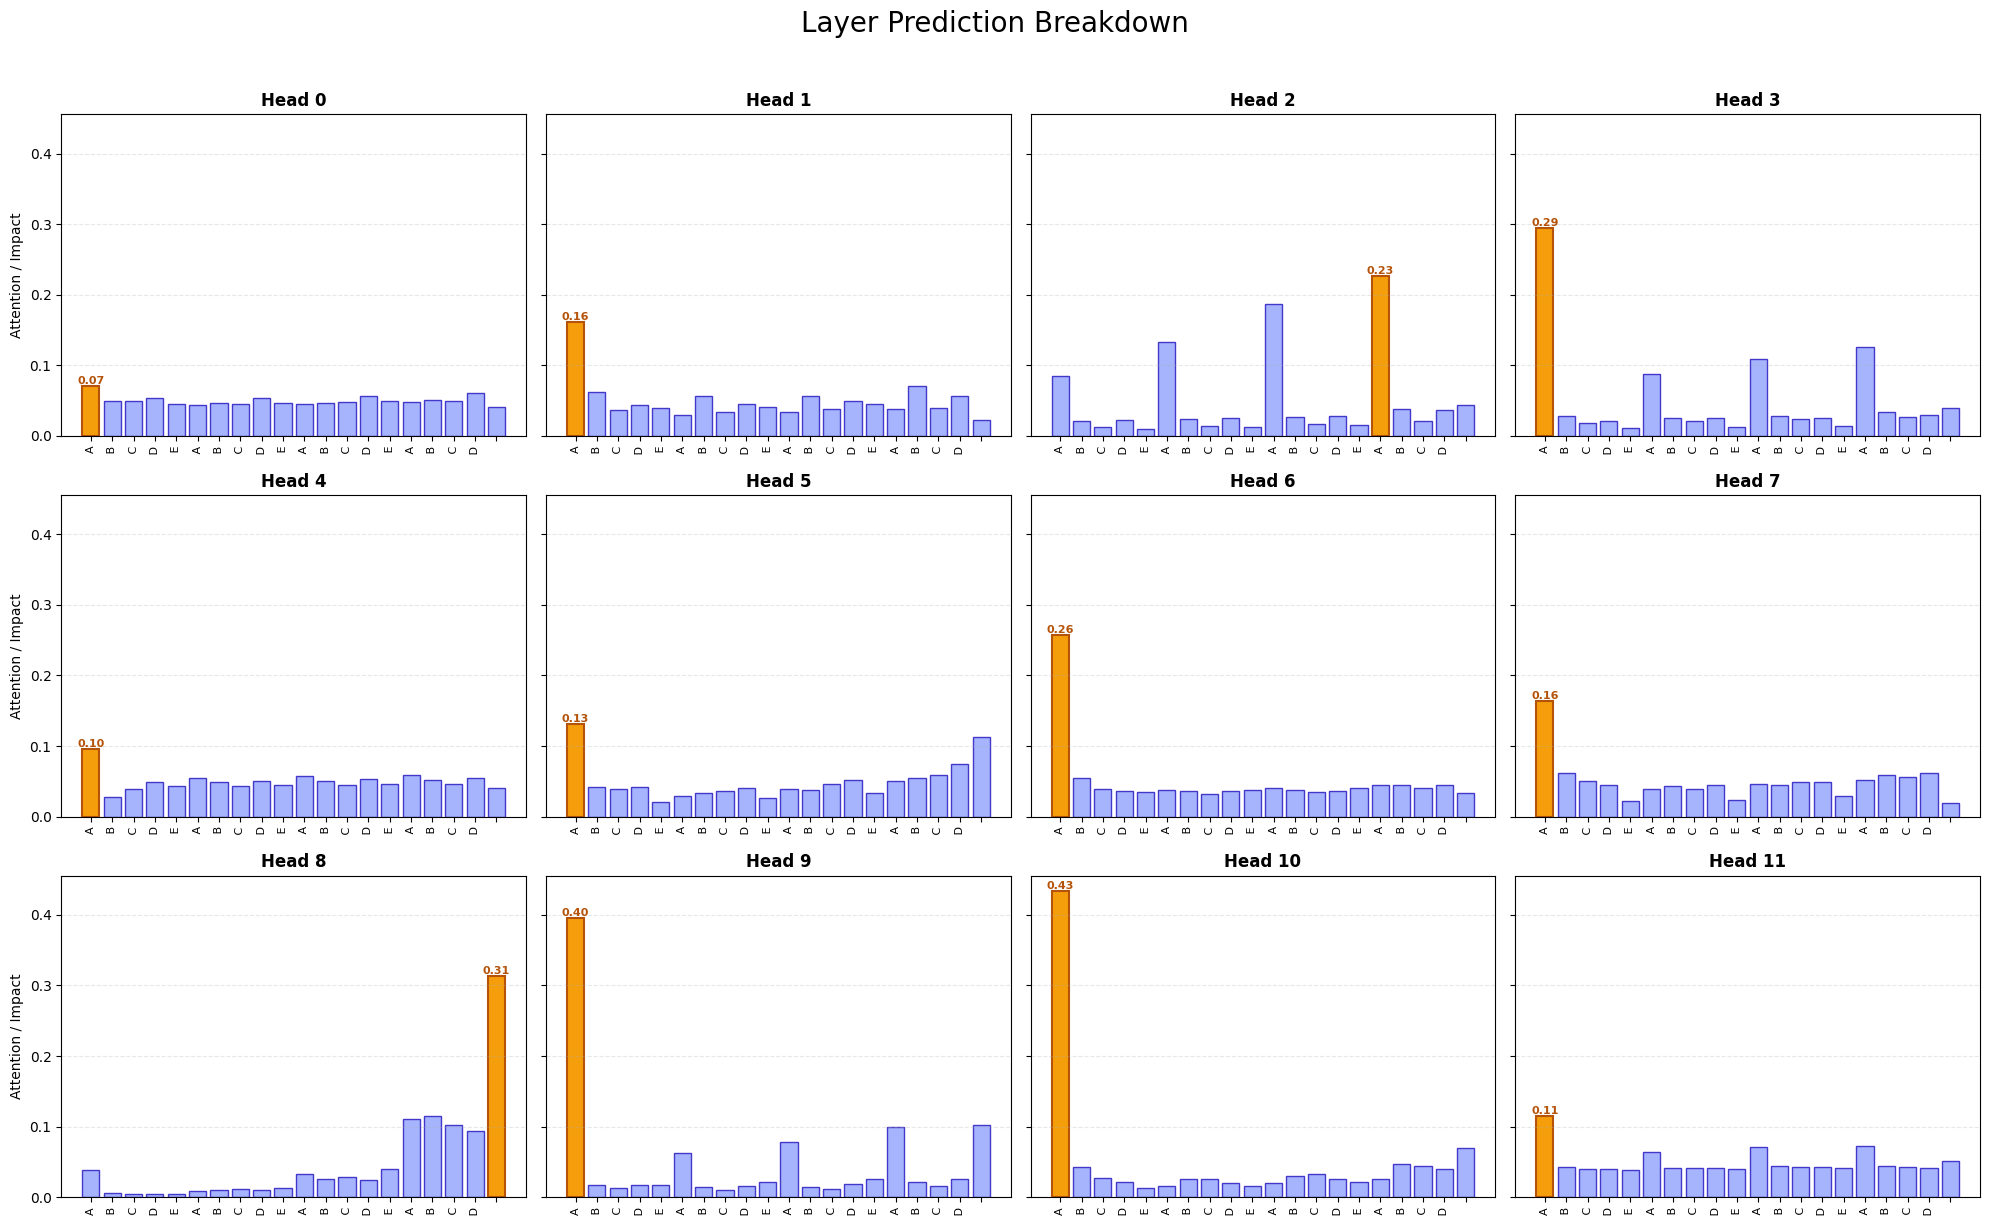

In [28]:
plot_all_heads_next_token(cache['pattern'][1], tokens)

In [29]:
def plot_attention_heads(qk_scores, tokens, title = '' ,figsize=(15, 12)):
    """
    qk_scores: Tensor of shape (batch, num_heads, seq_len, seq_len)
    tokens: List of strings matching the seq_len
    """
    if torch.is_tensor(qk_scores):
        qk_scores_np = qk_scores.detach().cpu().numpy()
    else:
        qk_scores_np = qk_scores
    
    # Validation
    batch, num_heads, seq_len, _ = qk_scores_np.shape
    if len(tokens) != seq_len:
        print(f"Warning: Token list length ({len(tokens)}) does not match sequence length ({seq_len})")
        # Truncate or pad tokens to match to prevent crash
        tokens = tokens[:seq_len] 

    # Calculate grid size (e.g. for 12 heads, do 3x4 or 4x3)
    rows = int(np.ceil(num_heads / 4))
    cols = min(num_heads, 4)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    # Flatten axes array for easy iteration if it's multidimensional
    if num_heads > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
        
    fig.suptitle(title, fontsize=16)
    
    # Generate distinct colors for each head
    base_colors = plt.cm.tab20(np.linspace(0, 1, num_heads))
    decodeds = [enc.decode([i]) for i in tokens]
    for i in range(num_heads):
        ax = axes[i]
        
        # Create a custom colormap from White -> Head Color
        cmap = LinearSegmentedColormap.from_list(
            f'custom_cmap_{i}', 
            [(1, 1, 1, 0), base_colors[i]], 
            N=256
        )

        
        # Draw Heatmap
        sns.heatmap(
            qk_scores_np[0, i, :, :], 
            cmap=cmap,
            ax=ax,
            cbar=True,
            xticklabels=decodeds, # <--- PUT TOKENS ON X
            yticklabels=decodeds, # <--- PUT TOKENS ON Y
            vmin=0, 
            vmax=np.max(qk_scores_np[0, i, :, :])
        )
        
        ax.set_title(f'Head {i}')
        # Rotate labels so they don't overlap
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
        
    plt.tight_layout()
    return fig

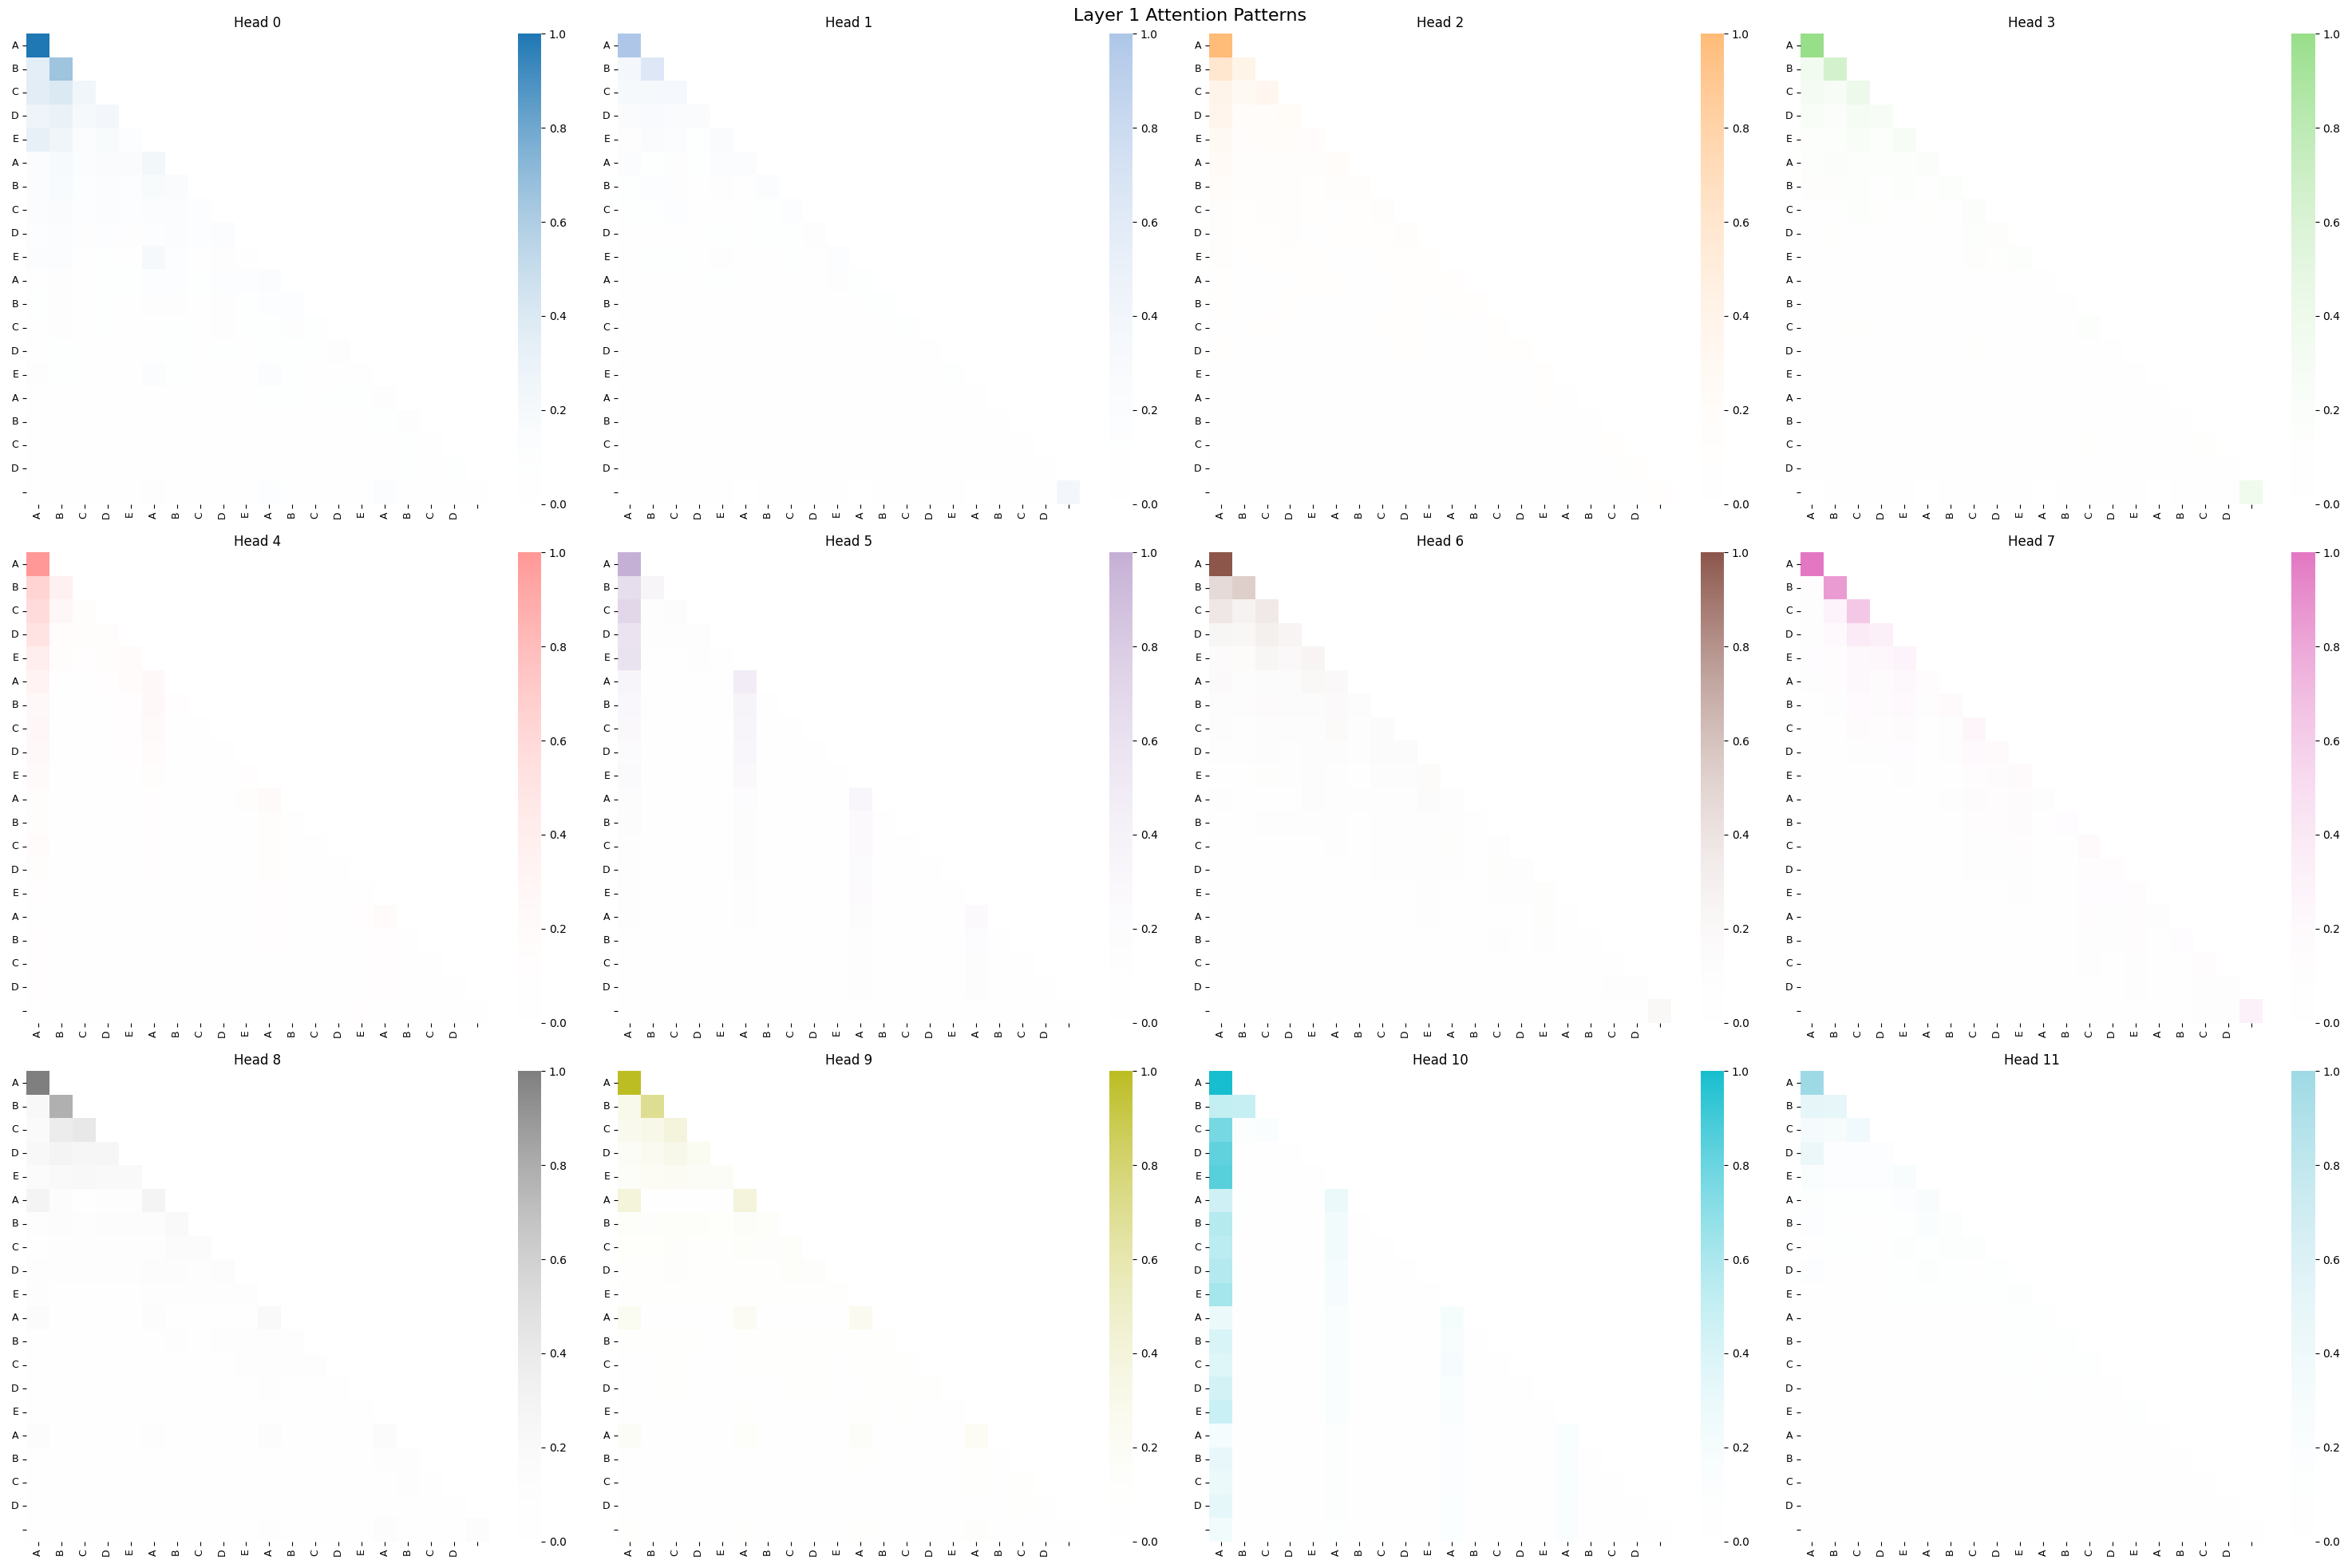

In [30]:
fig = plot_attention_heads(
    cache['pattern'][0], tokens, 'Layer 1 Attention Patterns ', (30, 20))
plt.show()

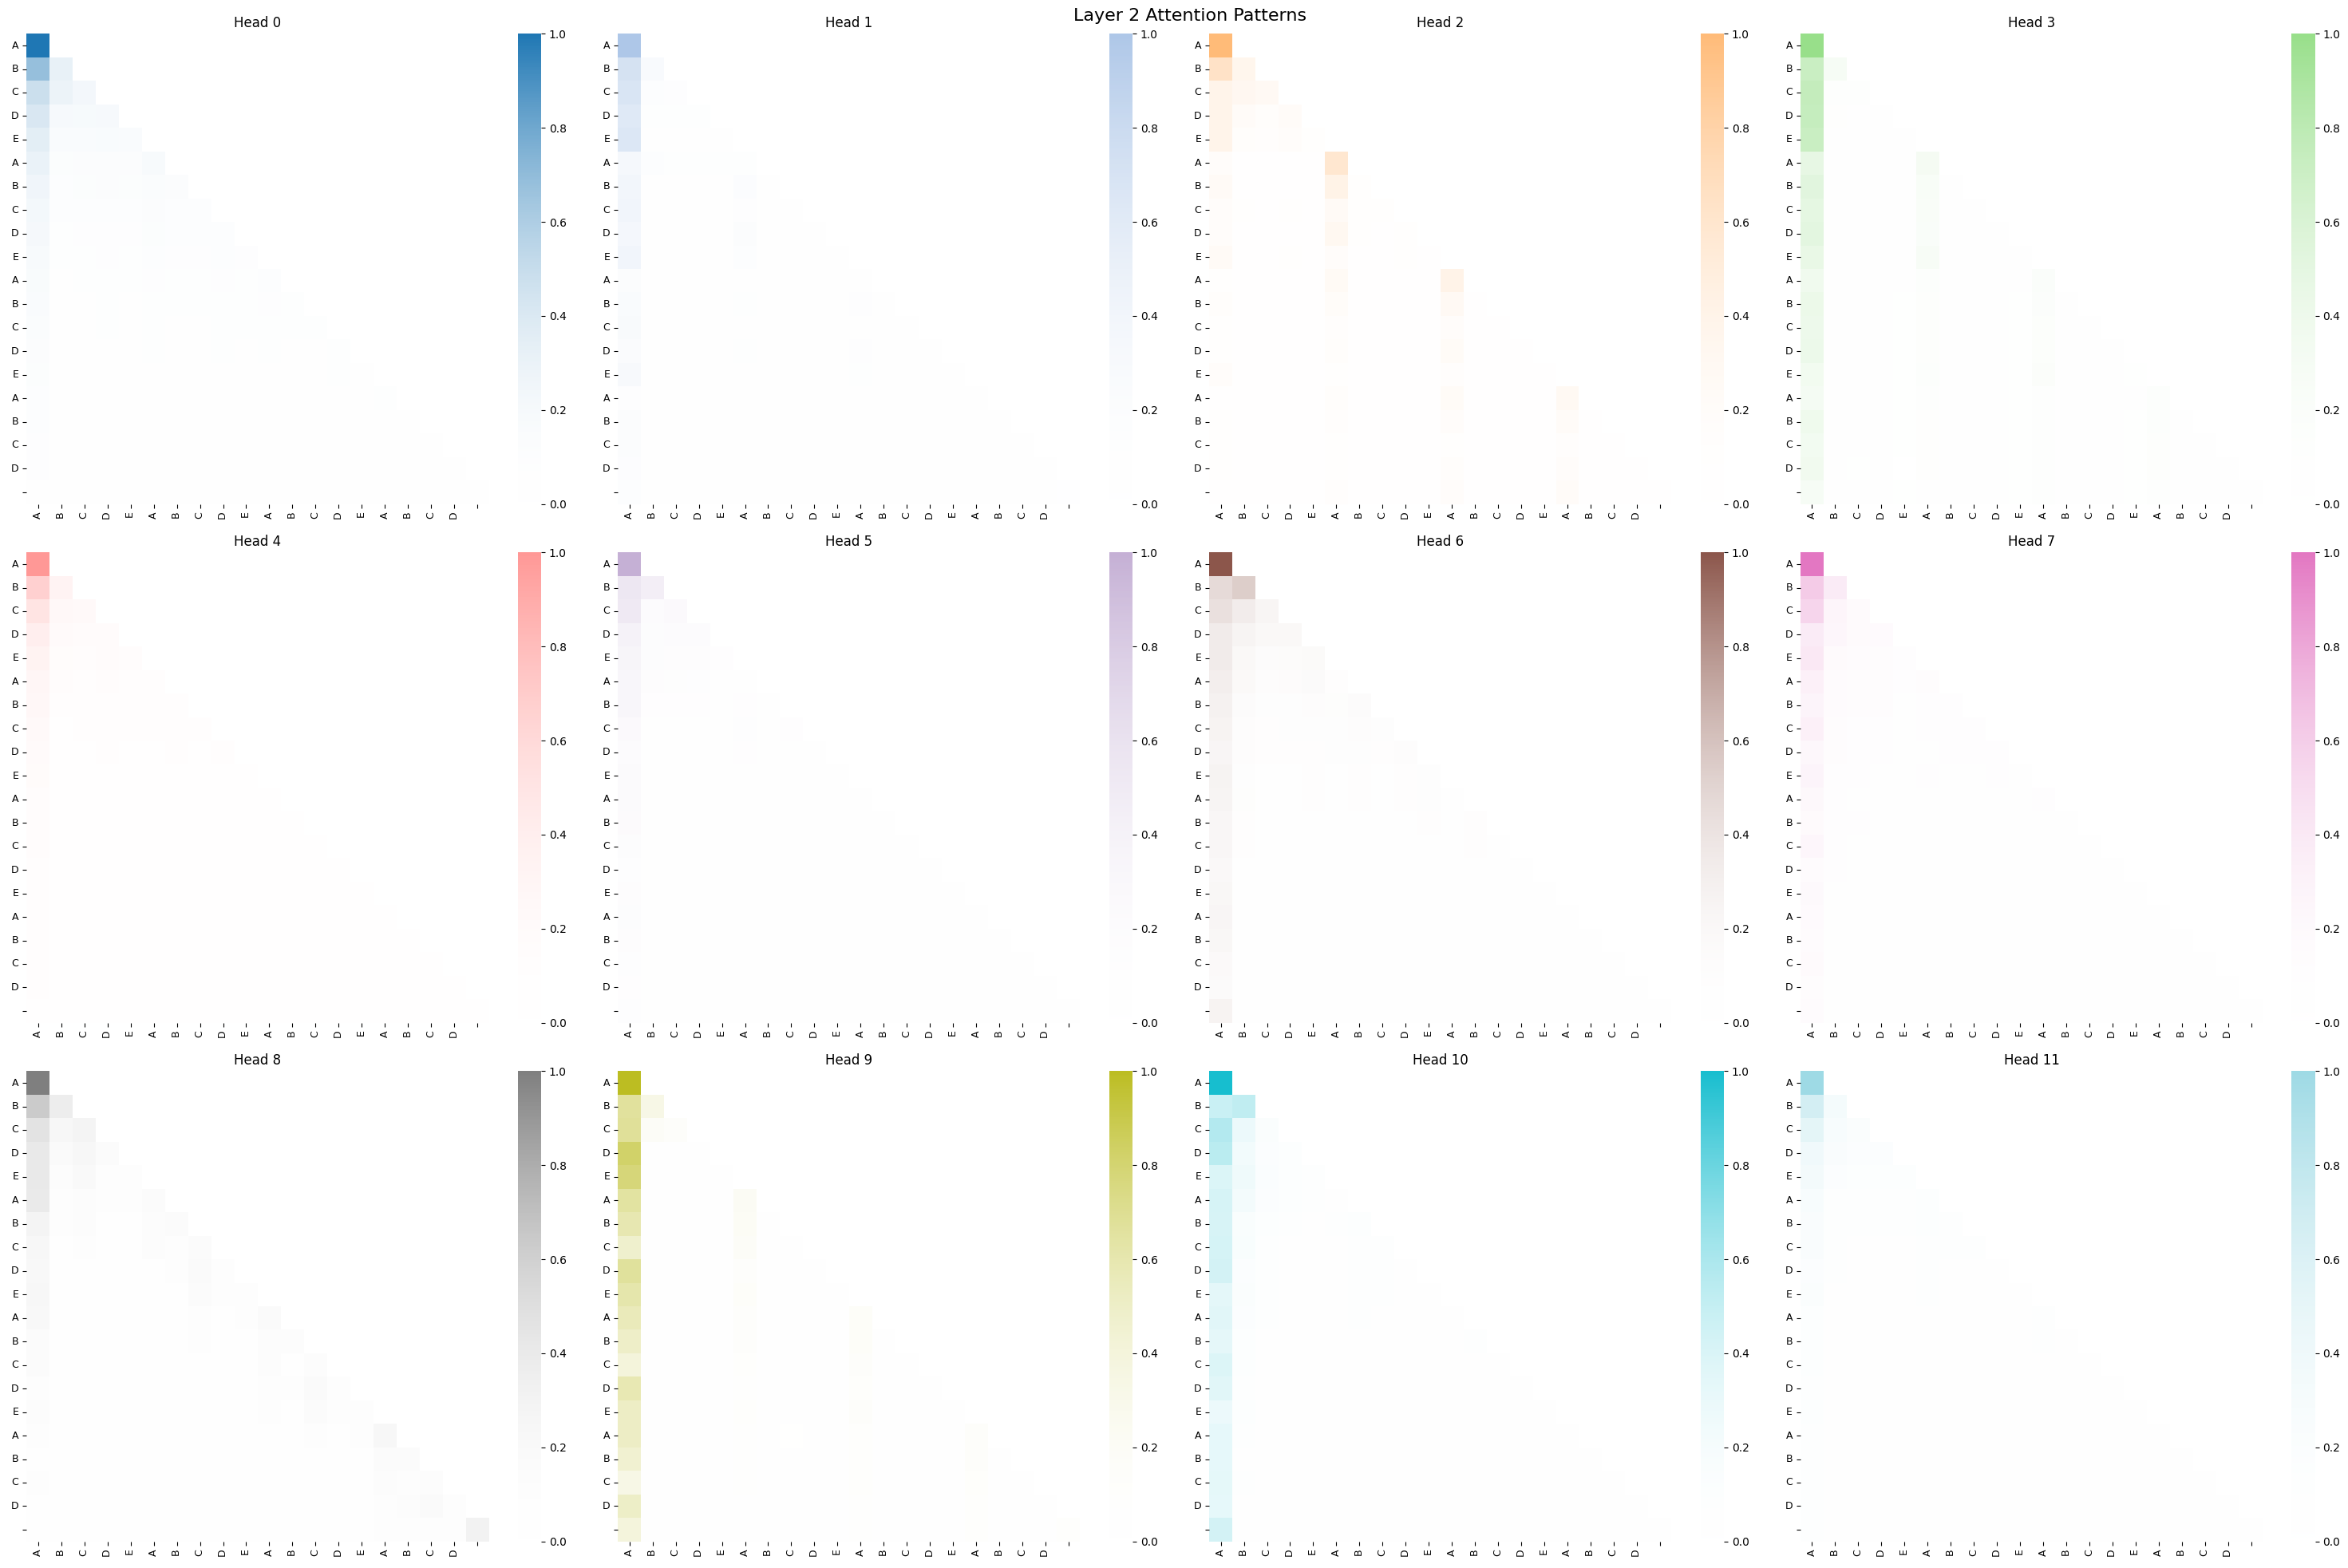

In [31]:
fig = plot_attention_heads(
    cache['pattern'][1], tokens, 'Layer 2 Attention Patterns ', (30, 20))
plt.show()

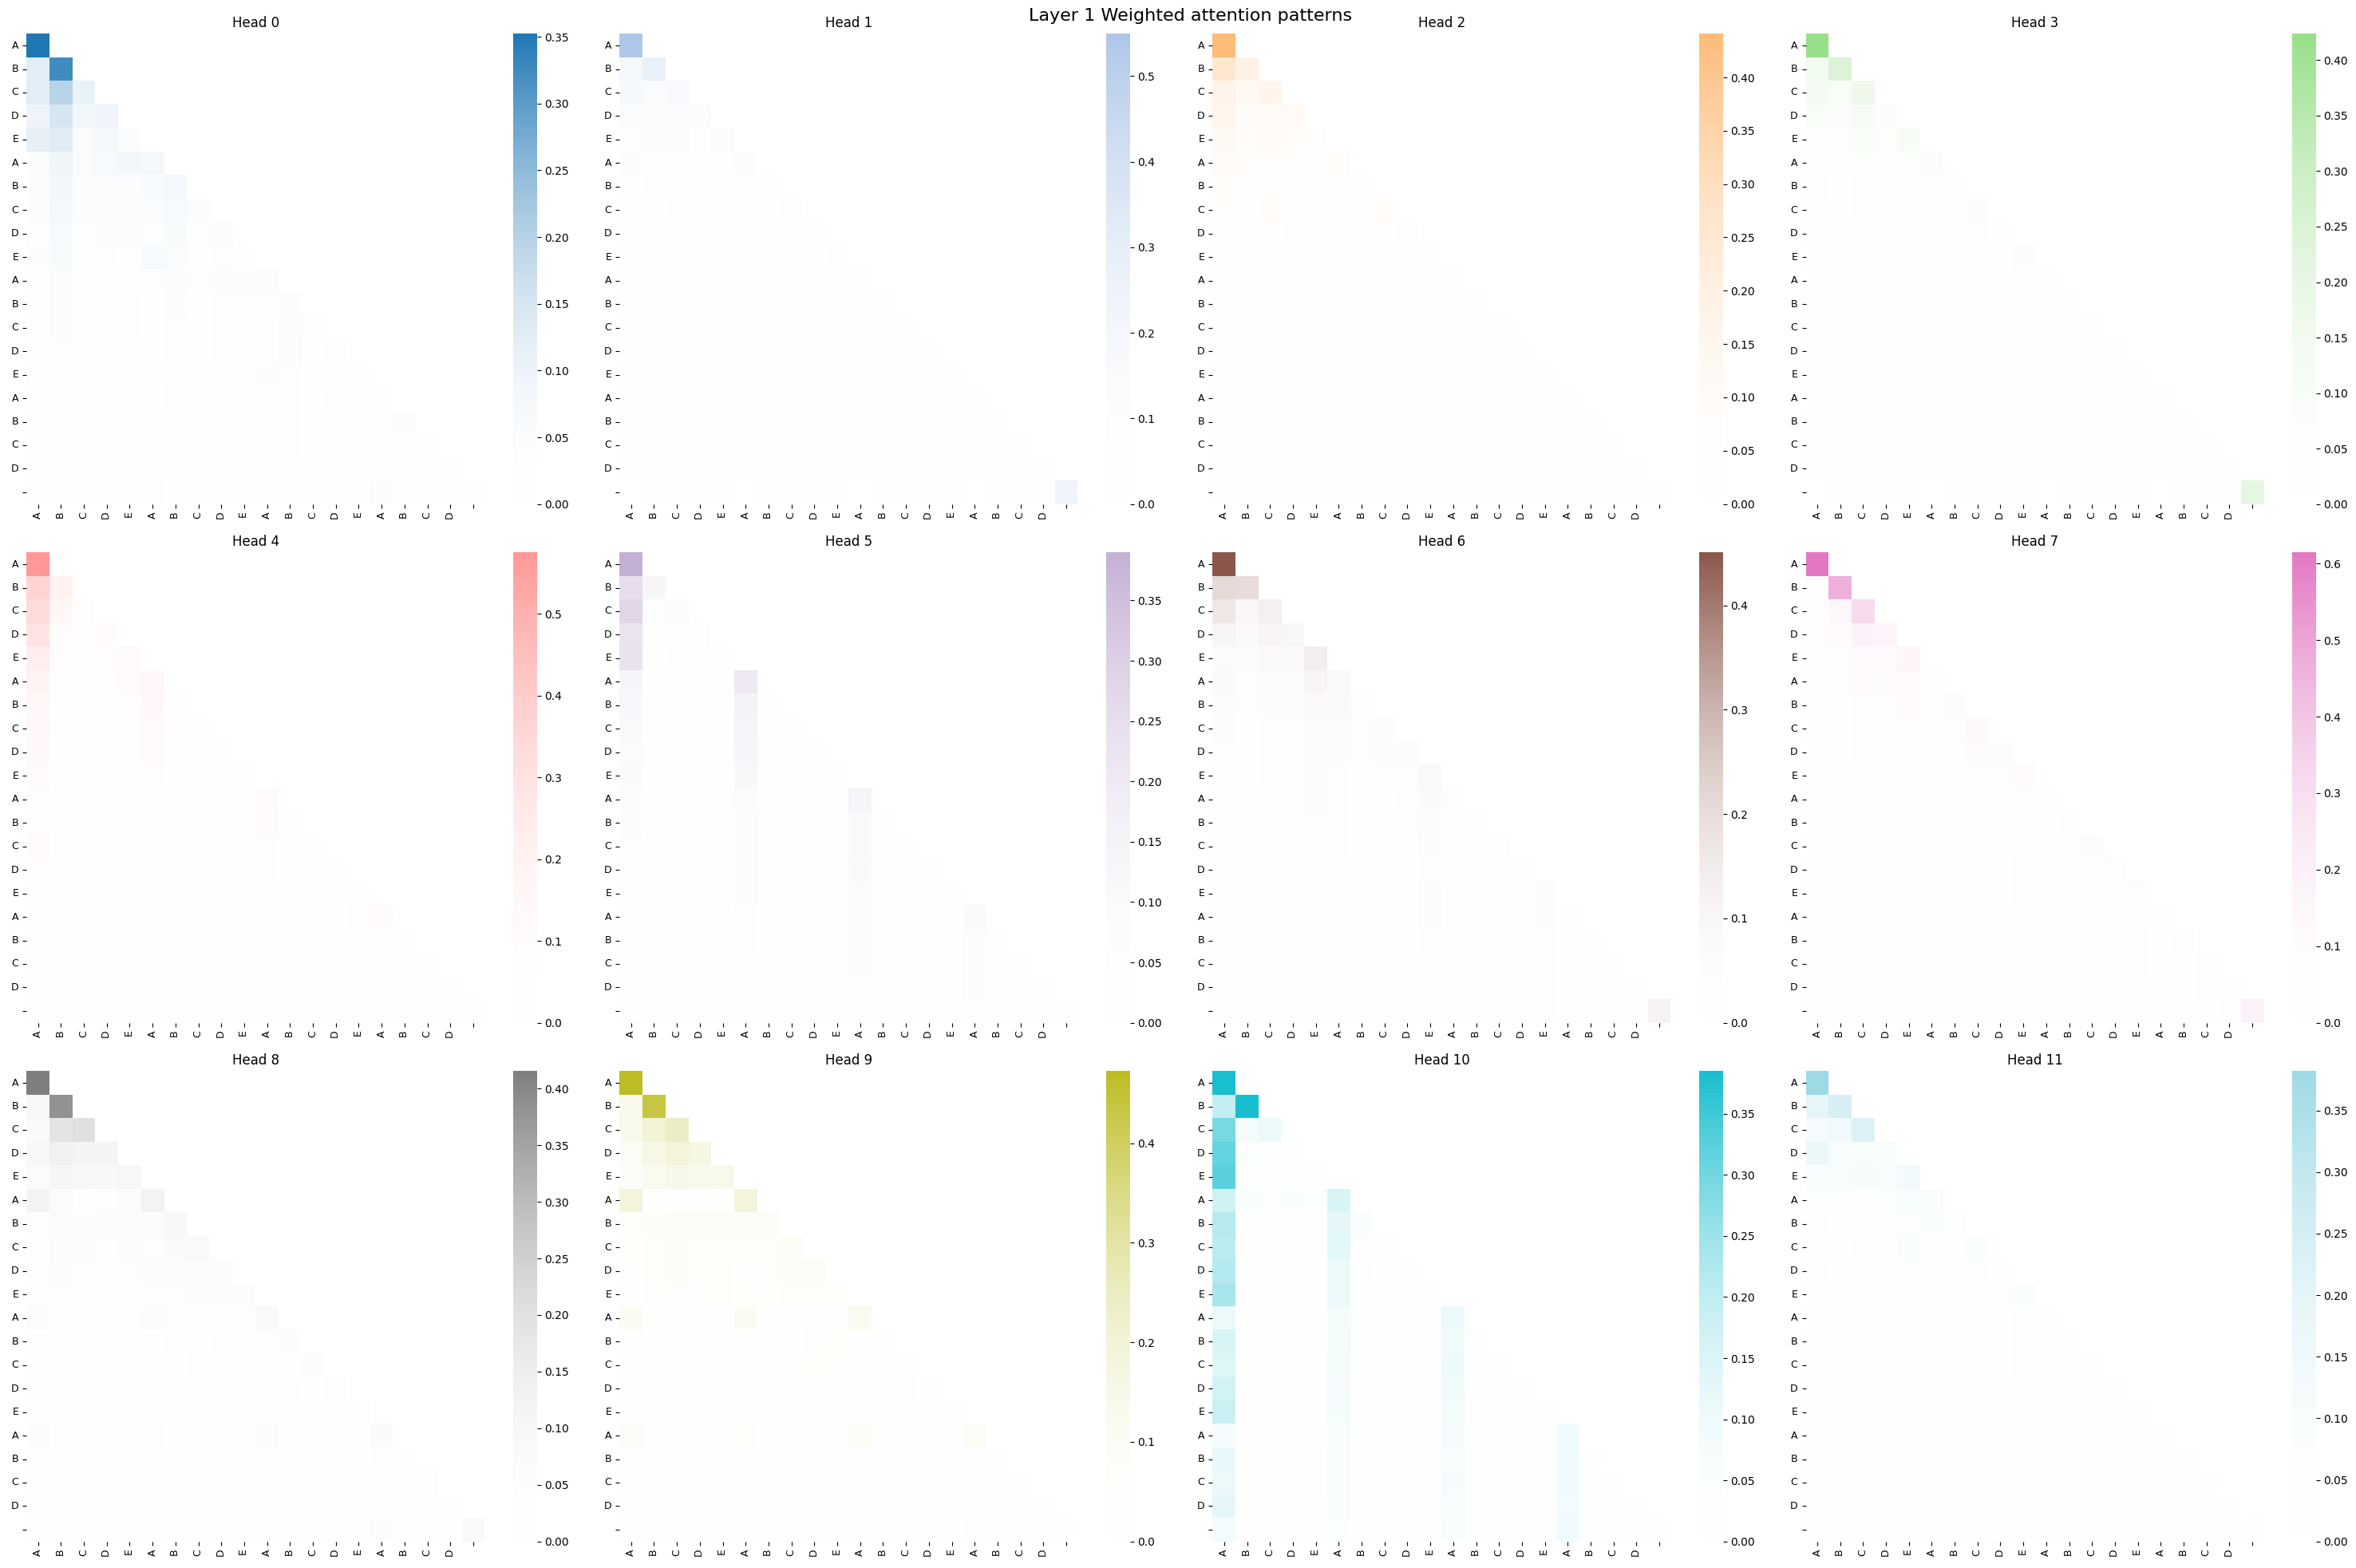

In [32]:
fig = plot_attention_heads(layer_1_weighted_contributions, tokens, 'Layer 1 Weighted attention patterns ', (30, 20))
plt.show()

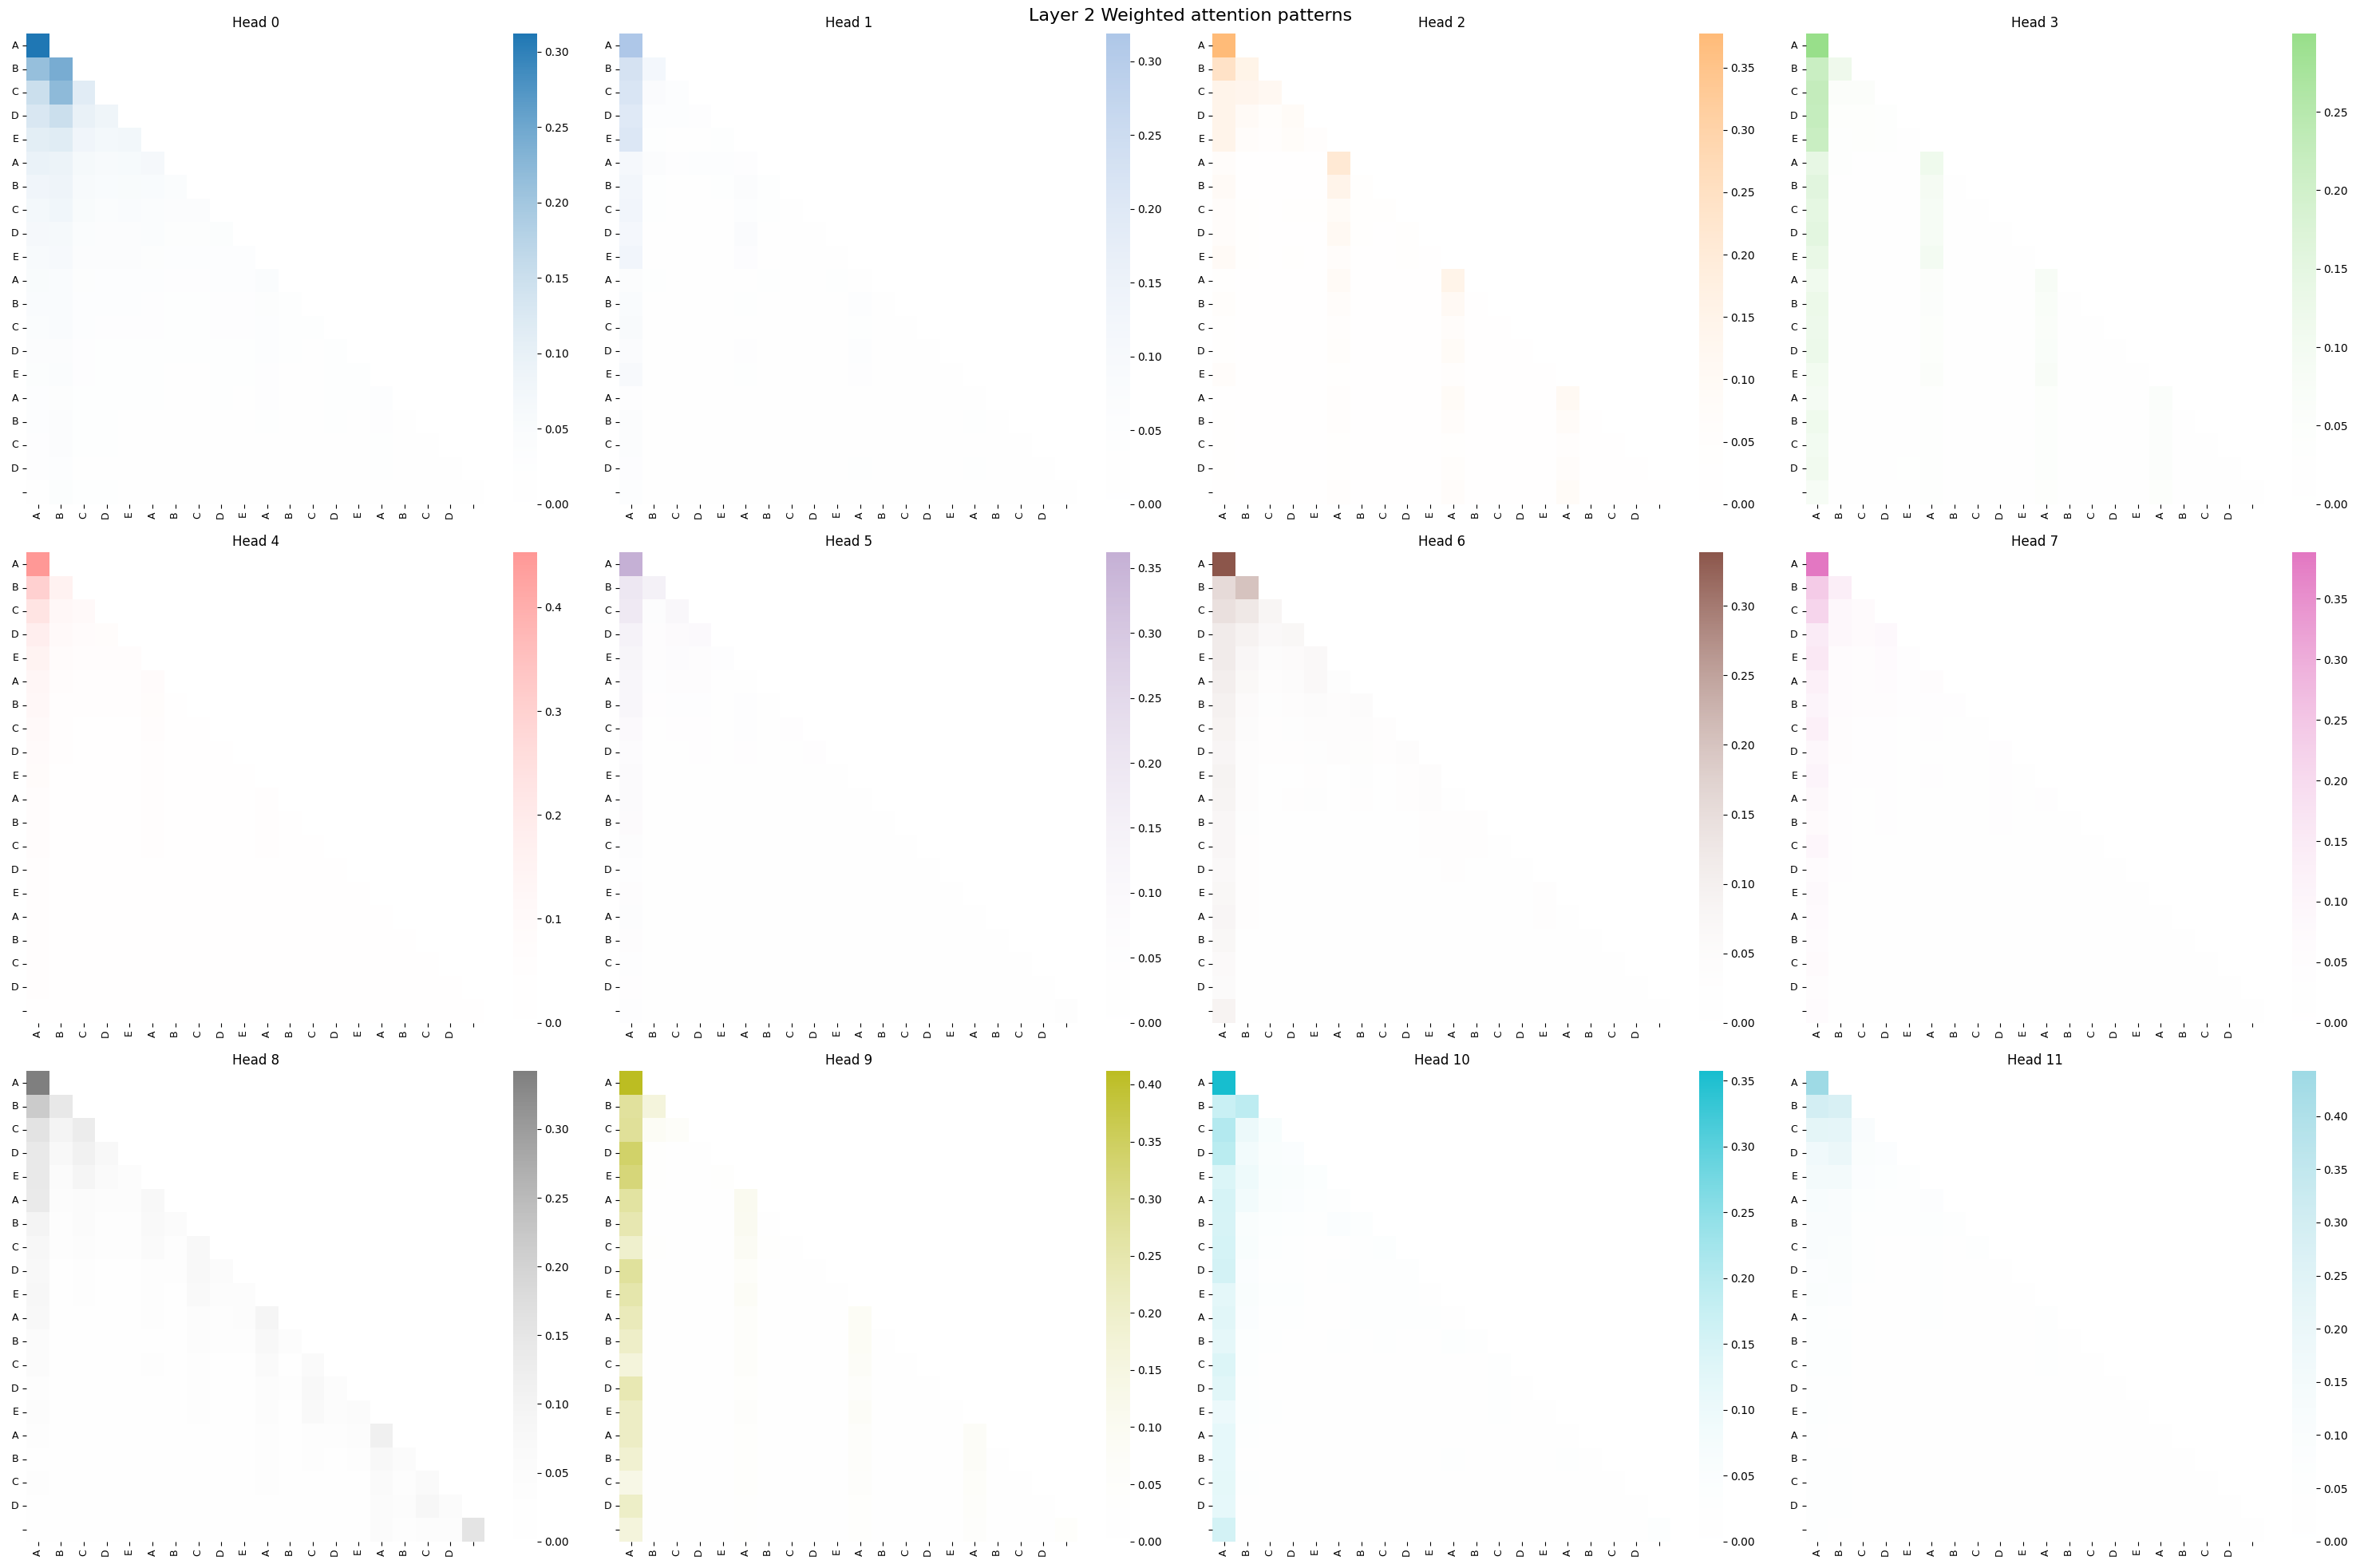

In [33]:
fig = plot_attention_heads(layer_2_weighted_contributions, tokens, 'Layer 2 Weighted attention patterns ', (30, 20))
plt.show()

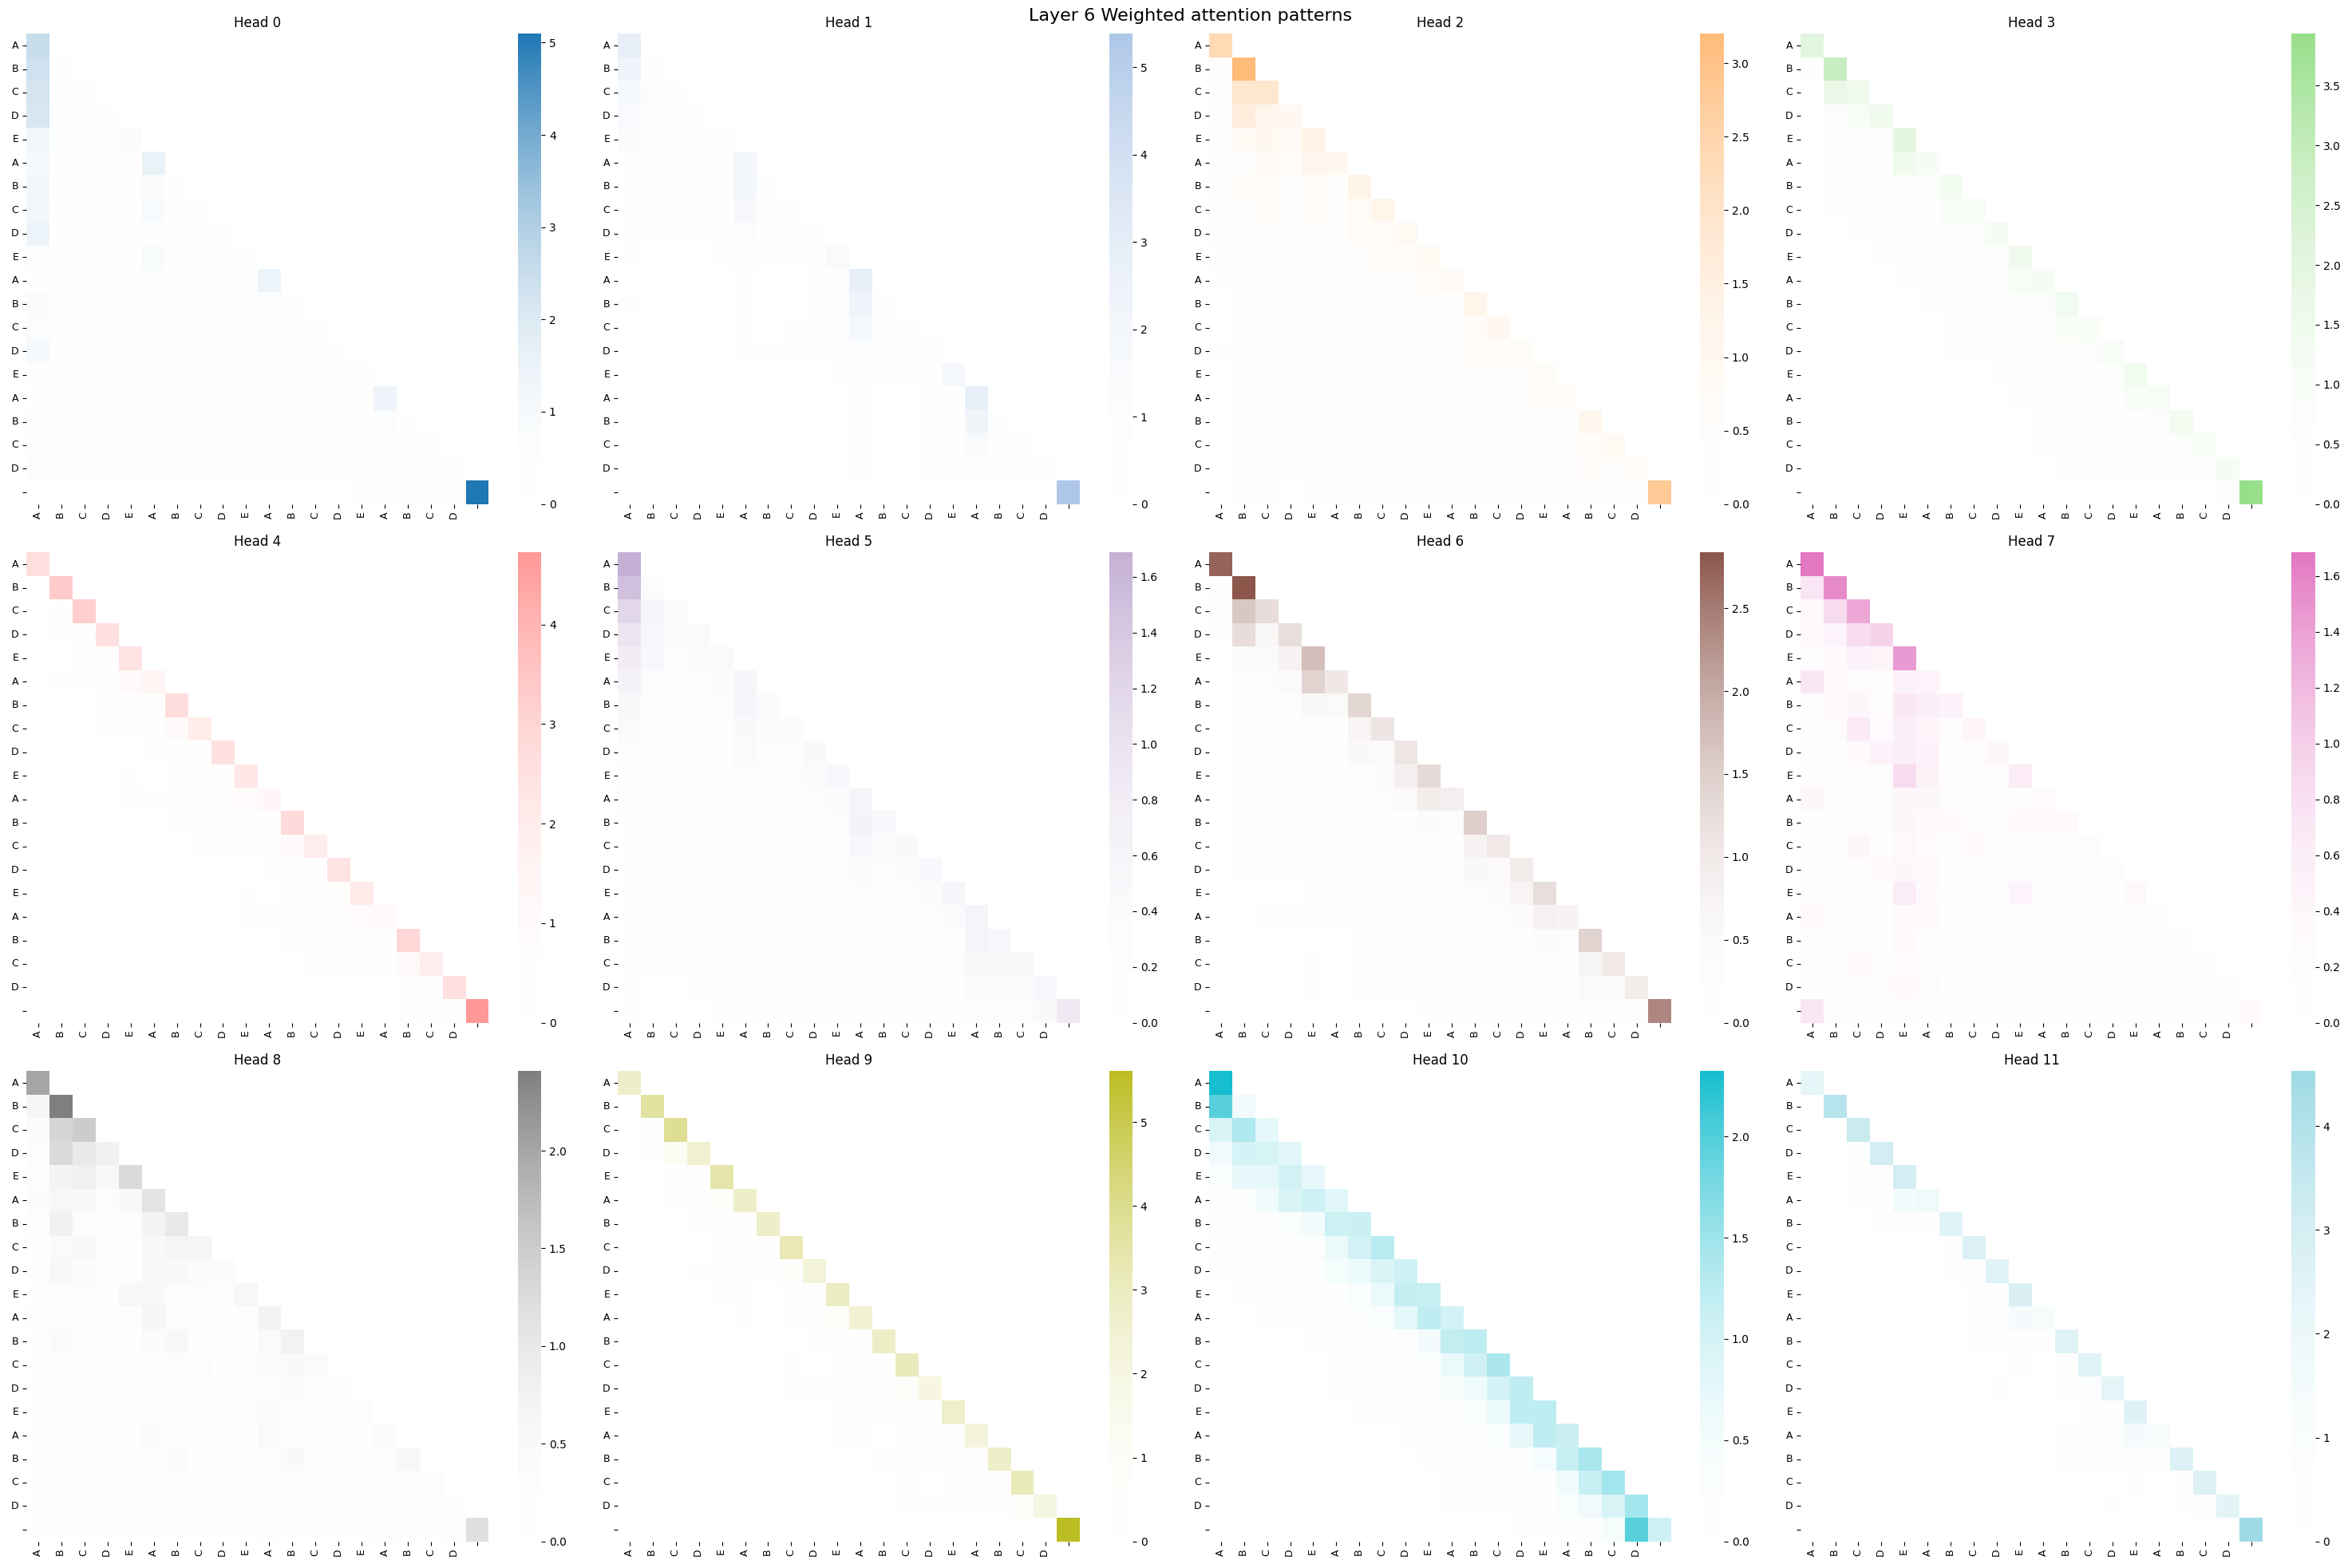

In [34]:
fig = plot_attention_heads(layer_6_weighted_contributions, tokens, 'Layer 6 Weighted attention patterns ', (30, 20))
plt.show()

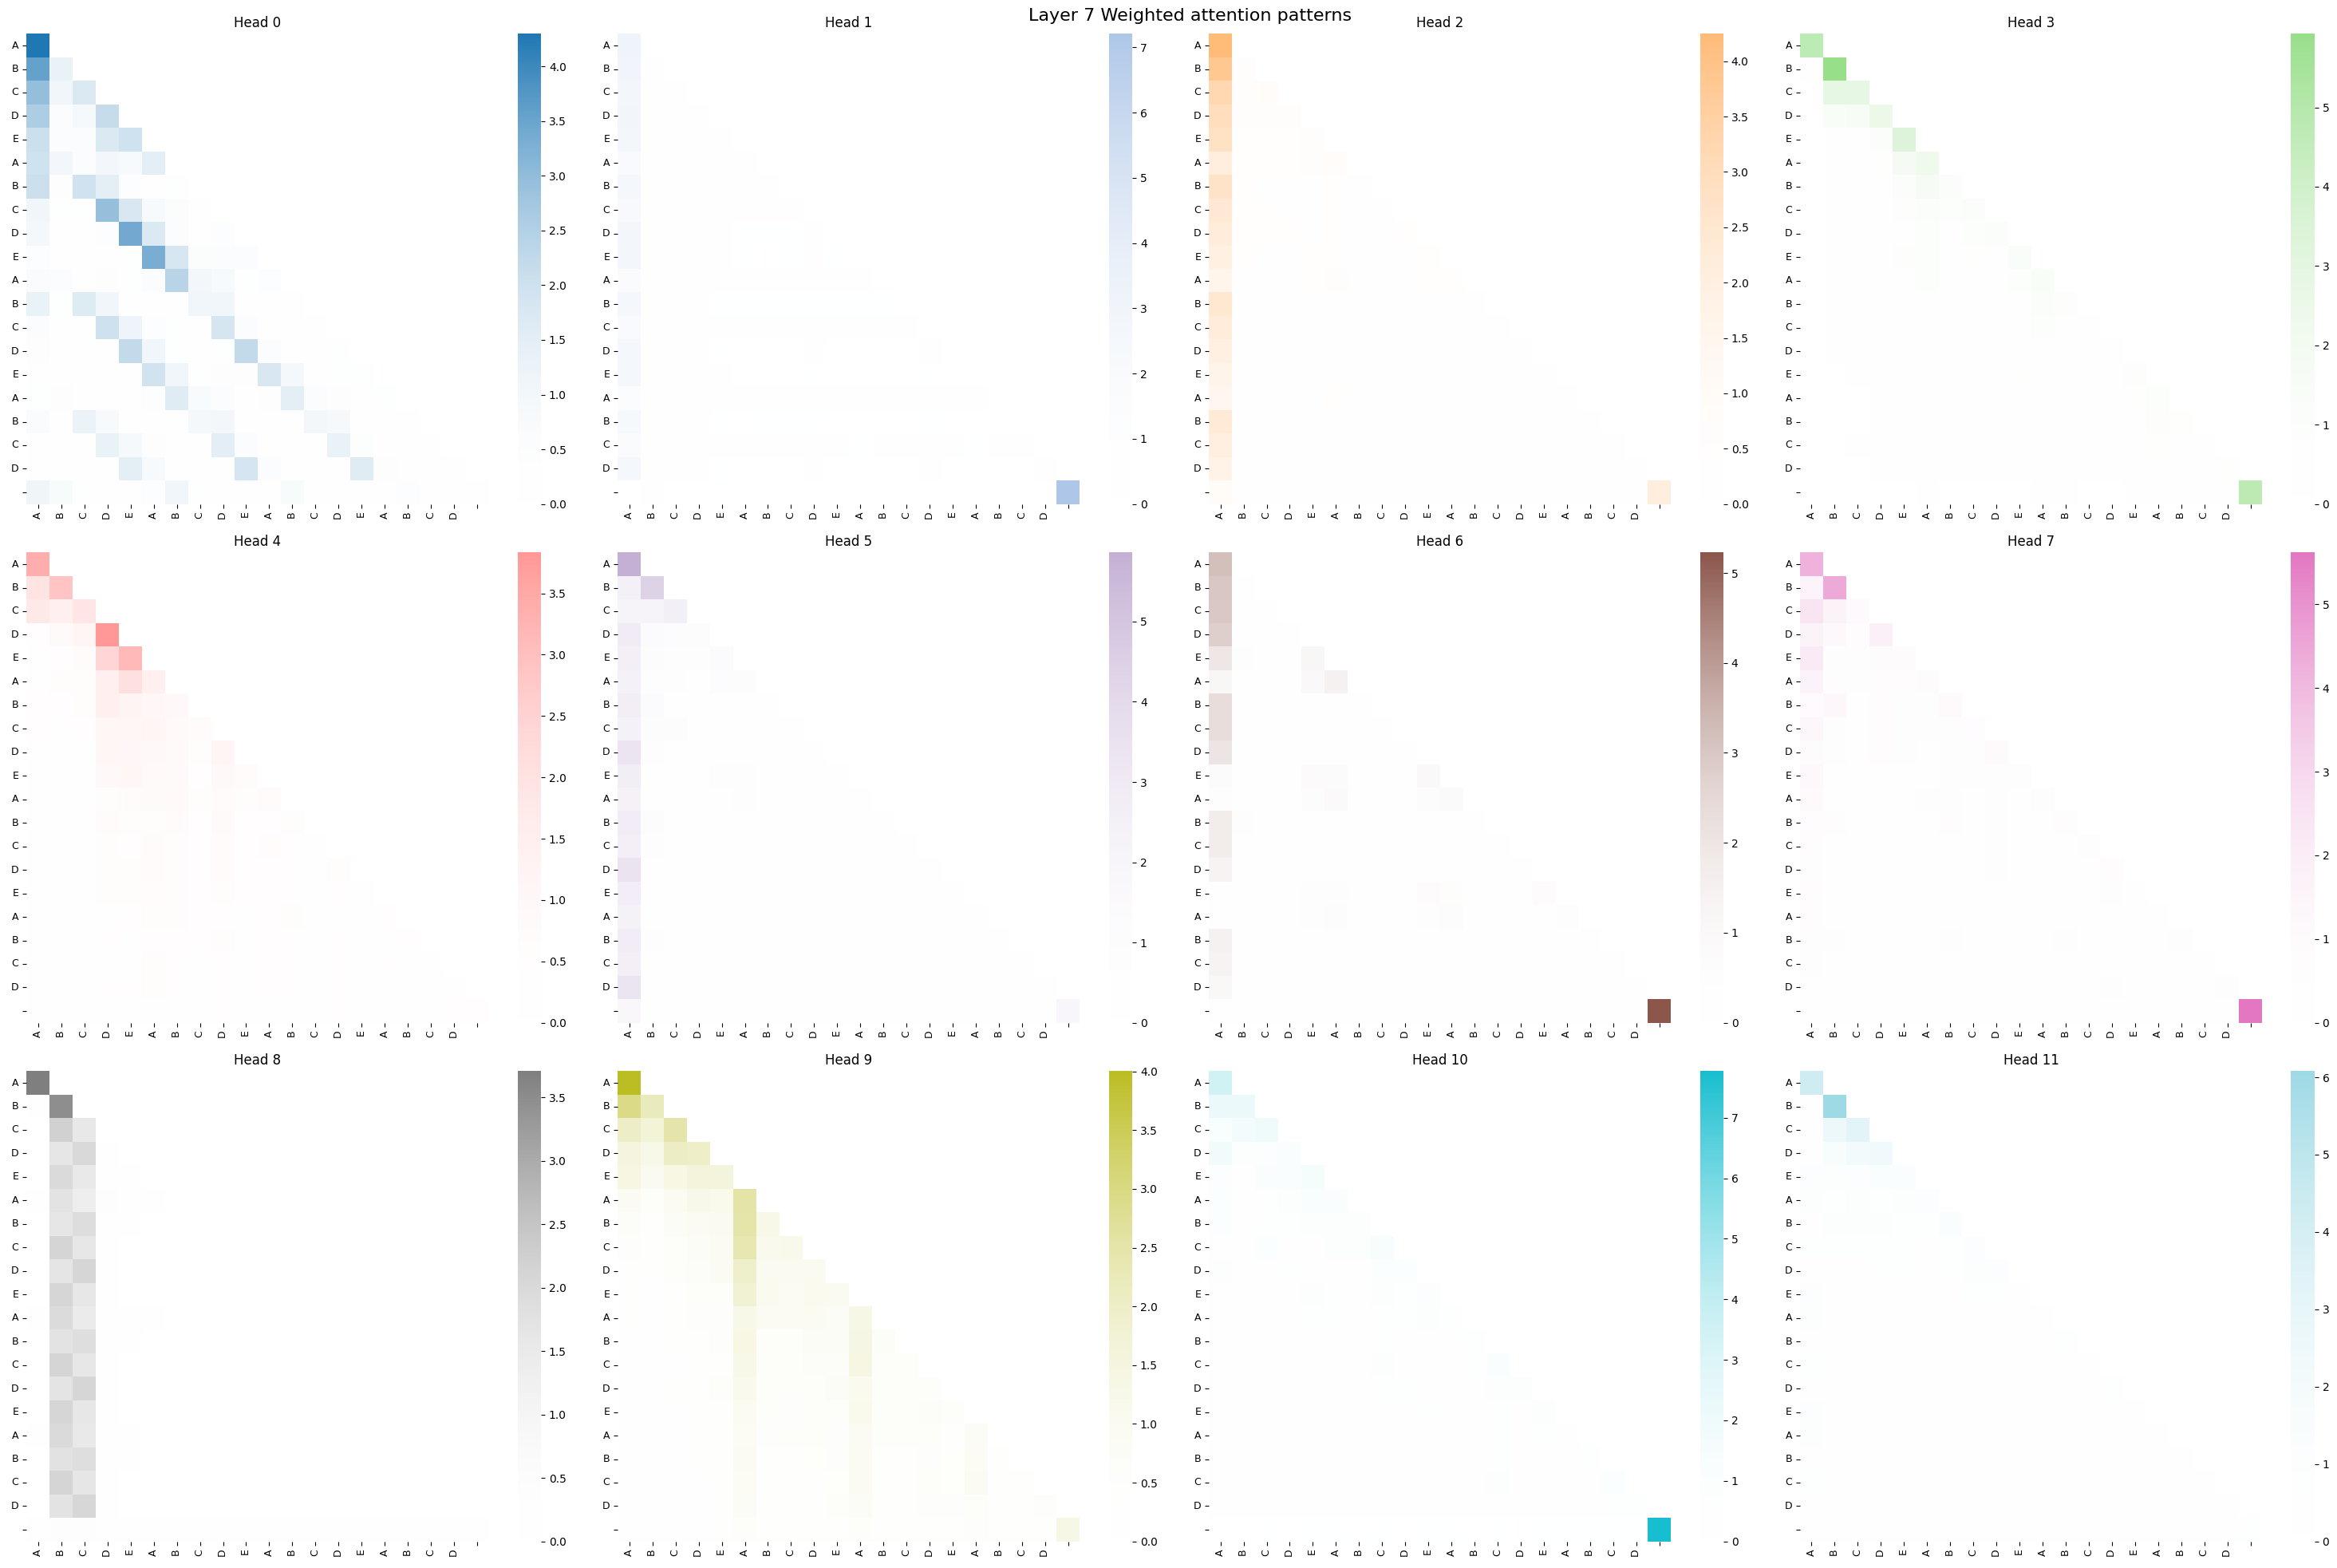

In [35]:
fig = plot_attention_heads(layer_7_weighted_contributions, tokens, 'Layer 7 Weighted attention patterns ', (30, 20))
plt.show()

In [36]:
import json
text = """Mr Dursley was privet driver. 
Mr Dursley was the director of a firm.
Mr Dursley was thin and blonde and had nearly twice the usual amount of neck.
Mr Dursley had a small son called Dudley. 
Mr Dursley"""

token_ids = enc.encode(text)
str_tokens = [enc.decode([t]).replace("\n", "\\n") for t in token_ids]
escaped_tokens = [html.escape(s) for s in str_tokens]

device = next(model.parameters()).device
x = torch.tensor([token_ids], dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    _, cache = model(x, return_all=True)

weighted_layers = []
head_labels = []

for layer_idx in range(model.num_layers):
    attn = cache['pattern'][layer_idx]
    v = cache['v'][layer_idx]
    v_norm = torch.norm(v, dim=-1).unsqueeze(-2)

    # Weight
    weighted = attn * v_norm
    weighted_layers.append(weighted[0])

    for h in range(model.n_heads):
        head_labels.append(f"L{layer_idx}H{h}")

full_tensor = torch.cat(weighted_layers, dim=0).cpu()
max_per_head = full_tensor.amax(dim=(1, 2)).numpy().tolist()
attn_data = full_tensor.numpy().round(4).tolist()

json_payload = json.dumps({
    "tokens": escaped_tokens,
    "headLabels": head_labels,
    "attention": attn_data,
    "maxPerHead": max_per_head
})

# ==========================================
# 2. GENERATE FINAL HTML
# ==========================================

html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Copying Detector Viz</title>
    <style>
        :root {{
            --bg: #050505;
            --panel: #111;
            --border: #222;
            --accent-cyan: #00f2ff;   /* Active Heads */
            --accent-red: #ff2a2a;    /* Destination (Future) */
            --accent-purple: #d500f9; /* Source (Past) */
        }}

        body {{
            background-color: var(--bg);
            color: #eee;
            font-family: 'Segoe UI', sans-serif;
            margin: 0;
            height: 100vh;
            display: flex;
            overflow: hidden;
        }}

        .sidebar {{
            width: 300px;
            background: var(--panel);
            border-right: 1px solid var(--border);
            padding: 20px;
            display: flex;
            flex-direction: column;
            gap: 20px;
        }}
        
        #zoomCanvas {{
            width: 100%;
            aspect-ratio: 1;
            background: #000;
            border: 1px solid #333;
            image-rendering: pixelated;
        }}

        .sidebar-text {{ font-size: 13px; color: #888; line-height: 1.5; }}
        .legend-box {{ display: inline-block; width: 10px; height: 10px; margin-right: 5px; }}

        .main-content {{
            flex: 1;
            padding: 40px;
            overflow-y: auto;
            display: flex;
            flex-direction: column;
            gap: 30px;
        }}

        .heads-grid {{
            display: grid;
            grid-template-columns: repeat({model.n_heads}, 1fr);
            gap: 6px;
        }}

        .head-card {{
            background: #0a0a0a;
            border: 1px solid #222;
            aspect-ratio: 1;
            position: relative;
            cursor: pointer;
            transition: all 0.2s;
        }}
        .head-card canvas {{ opacity: 0.3; width: 100%; height: 100%; }}
        
        /* Active Head Style */
        .head-card.active {{
            border-color: var(--accent-cyan);
            box-shadow: 0 0 15px rgba(0, 242, 255, 0.3);
            transform: scale(1.1);
            z-index: 10;
        }}
        .head-card.active canvas {{ opacity: 1.0; }}
        .head-card.dimmed {{ opacity: 0.1; }}

        .text-area {{
            background: var(--panel);
            padding: 30px;
            border-radius: 4px;
            line-height: 2.2;
            font-family: 'Consolas', monospace;
            font-size: 15px;
            white-space: pre-wrap;
        }}

        .token {{
            padding: 2px 3px;
            border-radius: 3px;
            cursor: pointer;
            color: #666;
            border: 1px solid transparent;
            transition: all 0.1s;
        }}
        .token:hover {{ color: #fff; border-color: #fff; }}
        
        /* --- HIGHLIGHT STYLES --- */
        
        /* RED: Destination (When hovering a Head) */
        .token.highlight-dest {{
            background-color: rgba(255, 42, 42, 0.3);
            color: #fff;
            box-shadow: 0 0 5px rgba(255, 42, 42, 0.5);
        }}

        /* PURPLE: Source (When hovering a Token) */
        .token.highlight-source {{
            background-color: rgba(213, 0, 249, 0.4); /* Purple */
            color: #fff;
            box-shadow: 0 0 8px rgba(213, 0, 249, 0.6);
            font-weight: bold;
        }}

        /* The token currently being hovered */
        .token.current {{
            border: 1px solid yellow !important;
            background: rgba(255, 255, 0, 0.1);
            color: #fff;
        }}
        
        .locked {{ border: 1px solid #fff !important; }}

    </style>
</head>
<body>

    <div class="sidebar">
        <div>
            <div id="zoomLabel" style="font-weight:bold; color:#fff; margin-bottom:10px;">Hover a Head</div>
            <canvas id="zoomCanvas" width="{len(str_tokens)}" height="{len(str_tokens)}"></canvas>
        </div>
        <div class="sidebar-text">
            <p><strong>Mode 1: Hover Head</strong><br>
            <span class="legend-box" style="background:var(--accent-red)"></span>Red Text: Destination<br>
            "Where is this head writing to?"</p>
            
            <p><strong>Mode 2: Hover Token</strong><br>
            <span class="legend-box" style="background:var(--accent-cyan)"></span>Cyan Heads: Active Heads<br>
            <span class="legend-box" style="background:var(--accent-purple)"></span>Purple Text: Source<br>
            "Where did info come FROM?"</p>
            
            <p><em>Click to Lock view.</em></p>
        </div>
    </div>

    <div class="main-content" id="mainArea">
        <div>
            <div style="font-size:10px; color:#555; margin-bottom:5px;">ATTENTION HEADS</div>
            <div id="headsGrid" class="heads-grid"></div>
        </div>

        <div>
            <div style="font-size:10px; color:#555; margin-bottom:5px;">PROMPT SEQUENCE</div>
            <div id="textContainer" class="text-area"></div>
        </div>
    </div>

    <script>
        const data = {json_payload};
        const nTokens = data.tokens.length;
        
        let lockedHead = null;
        let lockedToken = null;

        const headsGrid = document.getElementById('headsGrid');
        const textDiv = document.getElementById('textContainer');
        const zoomCanvas = document.getElementById('zoomCanvas');
        const zoomCtx = zoomCanvas.getContext('2d');
        const zoomLabel = document.getElementById('zoomLabel');

        // --- INIT ---
        data.headLabels.forEach((label, hIdx) => {{
            const div = document.createElement('div');
            div.className = 'head-card';
            div.id = `h-${{hIdx}}`;
            
            const cvs = document.createElement('canvas');
            cvs.width = nTokens;
            cvs.height = nTokens;
            drawMiniHeatmap(cvs, hIdx);
            div.appendChild(cvs);
            headsGrid.appendChild(div);

            div.addEventListener('mouseenter', () => {{ if(!lockedHead && !lockedToken) setHeadFocus(hIdx); }});
            div.addEventListener('mouseleave', () => {{ if(!lockedHead && !lockedToken) clearFocus(); }});
            div.addEventListener('click', (e) => {{
                e.stopPropagation();
                if(lockedHead === hIdx) unlock();
                else {{ unlock(); lockedHead = hIdx; setHeadFocus(hIdx); div.classList.add('locked'); }}
            }});
        }});

        data.tokens.forEach((str, tIdx) => {{
            const span = document.createElement('span');
            span.className = 'token';
            span.id = `t-${{tIdx}}`;
            span.innerHTML = str;
            textDiv.appendChild(span);

            span.addEventListener('mouseenter', () => {{ if(!lockedHead && !lockedToken) setTokenFocus(tIdx); }});
            span.addEventListener('mouseleave', () => {{ if(!lockedHead && !lockedToken) clearFocus(); }});
            span.addEventListener('click', (e) => {{
                e.stopPropagation();
                if(lockedToken === tIdx) unlock();
                else {{ unlock(); lockedToken = tIdx; setTokenFocus(tIdx); span.classList.add('locked'); }}
            }});
        }});

        document.getElementById('mainArea').addEventListener('click', unlock);

        // --- DRAWING HELPERS ---
        function drawMiniHeatmap(canvas, hIdx) {{
            const ctx = canvas.getContext('2d');
            const imgData = ctx.createImageData(nTokens, nTokens);
            const matrix = data.attention[hIdx];
            const max = data.maxPerHead[hIdx] || 1;

            for(let y=0; y<nTokens; y++) {{
                for(let x=0; x<nTokens; x++) {{
                    let val = matrix[y][x];
                    let norm = Math.pow(val/max, 2); // Contrast
                    const i = (y * nTokens + x) * 4;
                    imgData.data[i] = 100;
                    imgData.data[i+1] = 255;
                    imgData.data[i+2] = 255;
                    imgData.data[i+3] = norm * 255;
                }}
            }}
            ctx.putImageData(imgData, 0, 0);
        }}

        function drawZoomedMatrix(hIdx) {{
            if(hIdx === null) {{
                zoomCtx.fillStyle = '#000';
                zoomCtx.fillRect(0,0,nTokens,nTokens);
                return;
            }}
            const matrix = data.attention[hIdx];
            const max = data.maxPerHead[hIdx] || 1;
            const imgData = zoomCtx.createImageData(nTokens, nTokens);
            for(let i=0; i<nTokens*nTokens*4; i+=4) {{
                const val = matrix[Math.floor(i/4/nTokens)][(i/4)%nTokens];
                const norm = val/max;
                imgData.data[i] = norm * 50;
                imgData.data[i+1] = norm * 200;
                imgData.data[i+2] = norm * 255;
                imgData.data[i+3] = 255;
            }}
            zoomCtx.putImageData(imgData, 0, 0);
        }}

        // --- INTERACTION ---

        function setHeadFocus(hIdx) {{
            // MODE: DESTINATION (RED)
            zoomLabel.innerText = data.headLabels[hIdx];
            drawZoomedMatrix(hIdx);

            const matrix = data.attention[hIdx];
            // Sum destination columns
            const destScores = matrix.map(row => row.reduce((a,b)=>a+b, 0));
            const max = Math.max(...destScores, 0.0001);

            data.tokens.forEach((_, t) => {{
                let intensity = destScores[t] / max;
                if(intensity < 0.2) intensity = 0;
                else intensity = Math.pow(intensity, 2);

                if(intensity > 0.01) {{
                    const el = document.getElementById(`t-${{t}}`);
                    el.classList.add('highlight-dest');
                    el.style.backgroundColor = `rgba(255, 42, 42, ${{intensity * 0.5}})`;
                }}
            }});
        }}

        function setTokenFocus(tIdx) {{
            // MODE: SOURCE (PURPLE) & HEADS (CYAN)
            zoomLabel.innerText = "Current: " + tIdx;
            drawZoomedMatrix(null); // No specific head matrix to show

            // 1. Highlight Current Token (Yellow Border)
            document.getElementById(`t-${{tIdx}}`).classList.add('current');

            // 2. Identify Active Heads (Cyan)
            const headScores = data.attention.map(m => m[tIdx].reduce((a,b)=>a+b, 0));
            const maxHead = Math.max(...headScores, 0.0001);

            data.headLabels.forEach((_, h) => {{
                let intensity = headScores[h] / maxHead;
                intensity = Math.pow(intensity, 3); // High contrast
                
                const el = document.getElementById(`h-${{h}}`);
                if(intensity > 0.05) {{
                    el.classList.add('active');
                    el.style.opacity = intensity + 0.3;
                }} else {{
                    el.classList.add('dimmed');
                }}
            }});

            // 3. Identify SOURCE Tokens (Purple)
            // We need to sum up where ALL heads are looking FROM
            let sourceScores = new Array(nTokens).fill(0);
            
            data.attention.forEach(matrix => {{
                // matrix[tIdx] is the row of Attention FROM sources TO our tIdx
                matrix[tIdx].forEach((val, srcIdx) => {{
                    sourceScores[srcIdx] += val;
                }});
            }});

            // Normalize Source Scores
            // Filter self-attention to see copying better? (Optional, kept raw here)
            const maxSource = Math.max(...sourceScores, 0.0001);

            data.tokens.forEach((_, sIdx) => {{
                if(sIdx === tIdx) return; // Skip self for clearer viz of others

                let intensity = sourceScores[sIdx] / maxSource;
                if(intensity < 0.1) intensity = 0;
                else intensity = Math.pow(intensity, 2);

                if(intensity > 0.01) {{
                    const el = document.getElementById(`t-${{sIdx}}`);
                    el.classList.add('highlight-source');
                    el.style.backgroundColor = `rgba(213, 0, 249, ${{intensity * 0.6}})`;
                }}
            }});
        }}

        function clearFocus() {{
            drawZoomedMatrix(null);
            zoomLabel.innerText = "Hover a Head";

            // Clear Classes
            document.querySelectorAll('.head-card').forEach(e => {{
                e.classList.remove('active', 'dimmed');
                e.style.opacity = '';
            }});
            document.querySelectorAll('.token').forEach(e => {{
                e.classList.remove('highlight-dest', 'highlight-source', 'current');
                e.style.backgroundColor = '';
                e.style.opacity = '1';
            }});
        }}

        function unlock() {{
            lockedHead = null;
            lockedToken = null;
            document.querySelectorAll('.locked').forEach(e => e.classList.remove('locked'));
            clearFocus();
        }}
    </script>
</body>
</html>
"""

with open("viz.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("Generated: viz.html")

Generated: viz.html


In [37]:
def qk_ov_token_circuits(model, source_token_id, layer_idx=0, head=0, topk=6, enc=None, verbose=True):
    """
    Analyze QK and OV circuits for a specific source token.
    
    Args:
        model: Transformer model
        source_token_id: Vocab index of the source token
        layer_idx: Which layer to analyze (default: 0)
        head: Which attention head to use (default: 0)
        topk: Number of top tokens to return (default: 6)
        enc: Optional encoder for decoding tokens
        verbose: Whether to print results (default: True)
    
    Returns:
        qk_top: Top-k token indices for QK circuit
        ov_top: Top-k token indices for OV circuit
    """
    W_E = model.W_E.weight           # [vocab, d_model]
    
    # Extract QK and OV for the specified layer
    W_QK = extract_W_QK(model, layer_idx=layer_idx)  # [n_heads, d_model, d_model]
    W_OV = extract_W_OV(model, layer_idx=layer_idx)  # [n_heads, d_model, d_model]
    
    source_vec = W_E[source_token_id]   # [d_model]

    # QK circuit: DEST_TOKENS x [d_model] × W_QK × SOURCE_TOKEN_VEC
    # Compute: for each destination token embedding, compute QK score with source
    q_scores = W_E @ W_QK[head] @ source_vec      # [vocab]
    qk_top_vals, qk_top = torch.topk(q_scores, k=topk)
    
    # Decode tokens safely
    if enc is not None:
        qk_dec = []
        for idx in qk_top:
            try:
                decoded = enc.decode([idx.item()])
                qk_dec.append(decoded)
            except Exception:
                qk_dec.append(str(idx.item()))
    else:
        qk_dec = [str(idx.item()) for idx in qk_top]

    # OV: "If we attend to the SOURCE, what OUTPUT tokens does it boost?"
    W_U = model.W_U.weight          # [vocab, d_model]
    ov_vec = source_vec @ W_OV[head]    # [d_model]
    ov_out = ov_vec @ W_U.T             # [vocab]
    ov_top_vals, ov_top = torch.topk(ov_out, k=topk)
    
    # Decode tokens safely
    if enc is not None:
        ov_dec = []
        for idx in ov_top:
            try:
                decoded = enc.decode([idx.item()])
                ov_dec.append(decoded)
            except Exception:
                ov_dec.append(str(idx.item()))
    else:
        ov_dec = [str(idx.item()) for idx in ov_top]

    # Print results if verbose
    if verbose:
        source_str = enc.decode([source_token_id]) if enc is not None else str(source_token_id)
        print(f"Source Token: {source_str} (Layer {layer_idx}, Head {head})")
        print(f"Top {topk} QK Destination Tokens (tokens that most look TO this one):")
        for i, (tok, val) in enumerate(zip(qk_dec, qk_top_vals)):
            print(f"  {i+1}. '{tok}' ({val.item():.2f})")

        print(f"\nTop {topk} Output Tokens (out logit highest if attending to this source):")
        for i, (tok, val) in enumerate(zip(ov_dec, ov_top_vals)):
            print(f"  {i+1}. '{tok}' ({val.item():.2f})")
    
    return qk_top, ov_top


LAYER_IDX = 7  # Which layer to analyze (0-7)
HEAD_IDX = 0   # Which head to use (0-11)

openwebtext_tokens = [
    "perfect",
    "large",
    "lambda",
    "nbsp",
    "tall",
    "tuesday",
]

interesting_token_ids = []
for s in openwebtext_tokens:
    # For enc.encode, prefer first token if string encodes to multiple tokens
    tid_list = enc.encode(s)
    if len(tid_list) > 0:
        interesting_token_ids.append(tid_list[0])

# Remove duplicates, keep in insertion order
interesting_token_ids = list(dict.fromkeys(interesting_token_ids))

for tid in interesting_token_ids:
    print("\n" + "="*50)
    qk_top, ov_top = qk_ov_token_circuits(model, tid, layer_idx=LAYER_IDX, head=HEAD_IDX, topk=6, enc=enc)

    
table_rows = []
for tid in interesting_token_ids:
    qk_top, ov_top = qk_ov_token_circuits(model, tid, layer_idx=LAYER_IDX, head=HEAD_IDX, topk=20, enc=enc, verbose=False)
    
    if enc is not None:
        example_source = enc.decode([tid])
        qk_tokens = [enc.decode([i.item()]) if hasattr(i, 'item') else enc.decode([i]) for i in qk_top]
        ov_tokens = [enc.decode([i.item()]) if hasattr(i, 'item') else enc.decode([i]) for i in ov_top]
    else:
        example_source = str(tid)
        qk_tokens = [str(i.item()) if hasattr(i, 'item') else str(i) for i in qk_top]
        ov_tokens = [str(i.item()) if hasattr(i, 'item') else str(i) for i in ov_top]
    
    table_rows.append({
        "Source Token": example_source,
        "Destination Token (QK Top)": ", ".join(qk_tokens),
        "Out Token (OV Top)": ", ".join(ov_tokens),
    })

df = pd.DataFrame(table_rows)
df



Source Token: perfect (Layer 7, Head 0)
Top 6 QK Destination Tokens (tokens that most look TO this one):
  1. ' Cere' (0.35)
  2. ' hal' (0.31)
  3. ' ble' (0.29)
  4. ' Bam' (0.29)
  5. ' Deter' (0.29)
  6. ' rot' (0.28)

Top 6 Output Tokens (out logit highest if attending to this source):
  1. 'sticks' (0.66)
  2. 'stick' (0.61)
  3. 'ity' (0.59)
  4. 'ension' (0.50)
  5. 'urg' (0.48)
  6. 'ulator' (0.48)

Source Token: large (Layer 7, Head 0)
Top 6 QK Destination Tokens (tokens that most look TO this one):
  1. '-|' (0.48)
  2. ' mig' (0.38)
  3. ' Trou' (0.37)
  4. ' MAY' (0.36)
  5. ' Comm' (0.35)
  6. ' aust' (0.35)

Top 6 Output Tokens (out logit highest if attending to this source):
  1. 'mpeg' (0.76)
  2. 'rd' (0.71)
  3. 'mith' (0.66)
  4. 'backer' (0.64)
  5. 'hole' (0.57)
  6. 'eter' (0.54)

Source Token: lambda (Layer 7, Head 0)
Top 6 QK Destination Tokens (tokens that most look TO this one):
  1. ' Thank' (0.45)
  2. ' Received' (0.38)
  3. 'FORM' (0.38)
  4. '‑' (0.37)


NameError: name 'pd' is not defined

In [ ]:
openwebtext_tokens = [
    "perfect",
    "large",
    "lambda",
    "nbsp",
    "tall",
    "tuesday",
    'A B X F A B C X F'
]

interesting_token_ids = []
for s in openwebtext_tokens:
    # For enc.encode, prefer first token if string encodes to multiple tokens
    tid_list = enc.encode(s)
    if len(tid_list) > 0:
        interesting_token_ids.append(tid_list[0])

# Remove duplicates, keep in insertion order
interesting_token_ids = list(dict.fromkeys(interesting_token_ids))
# ==================== CONFIGURATION ====================
TOPK = 5  # Number of top tokens to show
TOPK_FINAL = 10  # Number of top tokens for final model output

# ==================== STEP 1: GET ACTUAL MODEL OUTPUTS & CONTRIBUTIONS ====================
print(f"{'='*80}")
print("Collecting actual model outputs and calculating contributions...")
print(f"{'='*80}\n")

device = next(model.parameters()).device
model.eval()

actual_outputs = {}
layer_contributions = {}  # [num_layers, topk] - contribution of each layer
head_contributions = {}   # [num_layers, n_heads, topk] - contribution of each head

def get_head_output(model, cache, layer_idx, head_idx, position=-1):
    """Get the output of a specific head at a specific layer"""
    pattern = cache['pattern'][layer_idx][0, head_idx, position, :]  # [seq_len]
    v = cache['v'][layer_idx][0, head_idx, :, :]  # [seq_len, d_head]
    head_output = torch.matmul(pattern, v)  # [d_head]
    
    # Project through W_O for this head
    d_head = model.d_head
    start = head_idx * d_head
    end = (head_idx + 1) * d_head
    W_O = model.W_O[layer_idx].weight[:, start:end]  # [d_model, d_head]
    head_output_dmodel = head_output @ W_O.T  # [d_model]
    
    return head_output_dmodel

with torch.no_grad():
    for tid in interesting_token_ids:
        source_str = enc.decode([tid]) if enc is not None else str(tid)
        input_tensor = torch.tensor([[tid]], dtype=torch.long, device=device)
        
        # Forward pass
        logits, cache = model(input_tensor, return_all=True)
        final_logits = logits[0, -1, :].cpu()
        final_probs = F.softmax(final_logits, dim=-1)
        
        # Get top predictions
        top_vals, top_idx = torch.topk(final_logits, k=TOPK_FINAL)
        top_probs = final_probs[top_idx]
        
        # Decode tokens
        top_tokens = [enc.decode([idx.item()]) if enc else str(idx.item()) 
                     for idx in top_idx]
        
        actual_outputs[source_str] = {
            'tokens': top_tokens,
            'probs': top_probs.cpu().numpy()
        }
        
        # Calculate contributions
        W_U = model.W_U.weight.cpu()
        W_E = model.W_E.weight.cpu()
        W_pos = model.W_pos.weight.cpu()
        
        # Get embedding (before any layers)
        embedding = (W_E[input_tensor[0, 0].cpu()] + W_pos[0]).cpu()  # [d_model]
        
        layer_contribs = []
        head_contribs_per_layer = []
        
        # Diagnostic: track layer output magnitudes
        layer_output_magnitudes = []
        
        for layer_idx in range(model.num_layers):
            # Get residual stream after this layer
            residual_after = cache['x'][layer_idx][0, -1, :].cpu()  # [d_model]
            
            # Calculate this layer's contribution (difference from previous)
            if layer_idx == 0:
                # Layer 0 contribution = residual_after - embedding
                layer_output = residual_after - embedding
            else:
                # Layer i contribution = residual_after[i] - residual_after[i-1]
                residual_before = cache['x'][layer_idx - 1][0, -1, :].cpu()
                layer_output = residual_after - residual_before
            
            # Track magnitude of layer output (diagnostic)
            layer_output_magnitudes.append(torch.norm(layer_output).item())
            
            # Project layer output through unembedding to get contribution
            layer_logits = layer_output @ W_U.T  # [vocab_size]
            layer_contribs.append(layer_logits[top_idx].cpu().numpy())
            
            # Head contributions within layer (already isolated per head)
            head_contribs = []
            for head_idx in range(model.n_heads):
                head_output = get_head_output(model, cache, layer_idx, head_idx, position=-1).cpu()
                head_logits = head_output @ W_U.T
                head_contribs.append(head_logits[top_idx].cpu().numpy())
            
            head_contribs_per_layer.append(np.array(head_contribs))
        
        layer_contributions[source_str] = np.array(layer_contribs)
        head_contributions[source_str] = np.array(head_contribs_per_layer)
        
        # Print diagnostic info for first token only
        if tid == interesting_token_ids[0]:
            print(f"\nDiagnostic: Layer output magnitudes (||layer_output||) for '{source_str}':")
            for i, mag in enumerate(layer_output_magnitudes):
                print(f"  L{i}: {mag:.4f}")
            print(f"  (If earlier layers have very small magnitudes, they may be undertrained)\n")

print("✓ Data collected\n")

# ==================== STEP 2: CREATE SUMMARY TABLES ====================
print(f"{'='*80}")
print("Creating summary tables...")
print(f"{'='*80}\n")

# ==================== CREATE SUMMARY TABLES ====================
import pandas as pd

# ==================== TABLE 1: ACTUAL OUTPUTS & LAYER CONTRIBUTIONS ====================
print("TABLE 1: Actual Model Outputs & Layer Contributions\n")

summary_rows = []
for tid in interesting_token_ids:
    source_str = enc.decode([tid]) if enc is not None else str(tid)
    
    actual_data = actual_outputs.get(source_str, {})
    actual_tokens = actual_data.get('tokens', [])
    actual_probs = actual_data.get('probs', [])
    
    layer_contribs = layer_contributions.get(source_str, np.zeros((model.num_layers, len(actual_tokens))))
    
    # Find which layer contributes most to top prediction
    if len(layer_contribs) > 0 and layer_contribs.shape[1] > 0:
        top_layer_contribs = layer_contribs[:, 0]  # Contributions to top-1 token
        max_layer = np.argmax(top_layer_contribs)
        max_layer_contrib = top_layer_contribs[max_layer]
    else:
        max_layer = 0
        max_layer_contrib = 0.0
    
    row = {
        "Source": source_str,
        "Top Prediction": actual_tokens[0] if len(actual_tokens) > 0 else "N/A",
        "Prob": f"{actual_probs[0]:.4f}" if len(actual_probs) > 0 else "N/A",
        "Max Contrib Layer": f"L{max_layer}",
        "Max Contrib": f"{max_layer_contrib:.3f}",
        **{f"L{i}": f"{top_layer_contribs[i]:.2f}" for i in range(model.num_layers)}
    }
    
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

try:
    from IPython.display import display
    display(summary_df)
except ImportError:
    print(summary_df)
    
    # ==================== DIAGNOSTIC: Check if earlier layers are making contributions ====================
    print("\n" + "="*80)
    print("DIAGNOSTIC: Layer Contribution Analysis")
    print("="*80 + "\n")
    
    # Analyze contributions across all tokens
    all_layer_contribs_combined = np.zeros(model.num_layers)
    for tid in interesting_token_ids:
        source_str = enc.decode([tid]) if enc is not None else str(tid)
        layer_contribs = layer_contributions.get(source_str, np.zeros((model.num_layers, 1)))
        if layer_contribs.shape[1] > 0:
            # Sum absolute contributions across all top predictions
            all_layer_contribs_combined += np.abs(layer_contribs[:, 0])
    
    # Normalize to percentages
    total_contrib = np.sum(all_layer_contribs_combined)
    if total_contrib > 0:
        contrib_percentages = (all_layer_contribs_combined / total_contrib) * 100
        print("Average contribution magnitude per layer (across all tokens):")
        for i in range(model.num_layers):
            print(f"  L{i}: {all_layer_contribs_combined[i]:.4f} ({contrib_percentages[i]:.1f}%)")
        print(f"\n⚠️  If earlier layers (L0-L6) show very small contributions (< 1%),")
        print(f"   the model may be undertrained or the checkpoint may not match the architecture.")
    else:
        print("⚠️  No contributions detected - check model training status.")
    
    # ==================== TABLE 2: HEAD CONTRIBUTIONS PER LAYER ====================
    print(f"\n\nTABLE 2: Head Contributions within Each Layer (for top prediction)\n")
    
    for layer_idx in range(model.num_layers):
        print(f"Layer {layer_idx}:\n")
        
        head_rows = []
        for tid in interesting_token_ids:
            source_str = enc.decode([tid]) if enc is not None else str(tid)
            
            actual_data = actual_outputs.get(source_str, {})
            actual_tokens = actual_data.get('tokens', [])
            
            head_contribs = head_contributions.get(source_str, np.zeros((model.num_layers, model.n_heads, len(actual_tokens))))
            layer_head_contribs = head_contribs[layer_idx, :, 0]  # [n_heads] - contributions to top-1 token
            
            max_head = np.argmax(layer_head_contribs)
            max_head_contrib = layer_head_contribs[max_head]
            
            row = {
                "Source": source_str,
                "Top Token": actual_tokens[0] if len(actual_tokens) > 0 else "N/A",
                "Max Head": f"H{max_head}",
                "Max Contrib": f"{max_head_contrib:.3f}",
                **{f"H{i}": f"{layer_head_contribs[i]:.2f}" for i in range(model.n_heads)}
            }
            
            head_rows.append(row)
        
        head_df = pd.DataFrame(head_rows)
        
        try:
            from IPython.display import display
            display(head_df)
        except ImportError:
            print(head_df)
    
    # ==================== TABLE 3: DOMINANCE SUMMARY ====================
    print(f"\n\nTABLE 3: Dominance Summary (Which layers/heads contribute most?)\n")
    
    # Count dominance for top prediction only
    layer_dominance = {f"L{i}": 0 for i in range(model.num_layers)}
    head_dominance = {f"L{i}": {f"H{j}": 0 for j in range(model.n_heads)} for i in range(model.num_layers)}
    
    for tid in interesting_token_ids:
        source_str = enc.decode([tid]) if enc is not None else str(tid)
        layer_contribs = layer_contributions.get(source_str, np.zeros((model.num_layers, 1)))
        head_contribs = head_contributions.get(source_str, np.zeros((model.num_layers, model.n_heads, 1)))
        
        # For top prediction only
        if layer_contribs.shape[1] > 0:
            layer_contribs_to_token = layer_contribs[:, 0]
            max_layer = np.argmax(layer_contribs_to_token)
            layer_dominance[f"L{max_layer}"] += 1
            
            head_contribs_in_layer = head_contribs[max_layer, :, 0]
            max_head = np.argmax(head_contribs_in_layer)
            head_dominance[f"L{max_layer}"][f"H{max_head}"] += 1
    
    # Layer dominance
    total = sum(layer_dominance.values())
    if total > 0:
        layer_dom_df = pd.DataFrame([{
            "Layer": layer,
            "Times Dominant": count,
            "Percentage": f"{(count / total * 100):.1f}%"
        } for layer, count in sorted(layer_dominance.items(), key=lambda x: x[1], reverse=True)])
        
        try:
            from IPython.display import display
            display(layer_dom_df)
        except ImportError:
            print(layer_dom_df)
    
    # Head dominance (per layer)
    print(f"\nHead Dominance per Layer:\n")
    for layer_idx in range(model.num_layers):
        layer_head_dom = head_dominance[f"L{layer_idx}"]
        total = sum(layer_head_dom.values())
        
        if total > 0:
            head_dom_df = pd.DataFrame([{
                "Layer": f"L{layer_idx}",
                "Head": head,
                "Times Dominant": count,
                "Percentage": f"{(count / total * 100):.1f}%"
            } for head, count in sorted(layer_head_dom.items(), key=lambda x: x[1], reverse=True) if count > 0])
            
            try:
                from IPython.display import display
                display(head_dom_df)
            except ImportError:
                print(head_dom_df)
   

print("\n✓ Analysis complete!")




Diagnostic: Layer output magnitudes (||layer_output||) for 'perfect':
  L0: 1.4194
  L1: 1.3228
  L2: 1.7391
  L3: 2.4160
  L4: 5.6961
  L5: 5.5041
  L6: 8.3562
  L7: 19.1165
  (If earlier layers have very small magnitudes, they may be undertrained)

✓ Data collected

Creating summary tables...

TABLE 1: Actual Model Outputs & Layer Contributions



,Source,Top Prediction,Prob,Max Contrib Layer,Max Contrib,L0,L1,L2,L3,L4,L5,L6,L7
0,perfect,ion,0.0440,L7,3.046,0.06,-0.22,0.07,0.36,0.59,0.92,2.55,3.05
1,large,-,0.0857,L7,4.477,0.06,-0.28,-0.27,-0.42,0.82,1.46,1.83,4.48
2,lambda,(,0.1065,L7,7.116,0.02,-0.21,-0.29,-0.16,-0.43,1.16,1.55,7.12
3,n,�,0.1518,L7,7.964,0.28,-0.09,-0.18,0.11,0.16,1.19,0.29,7.96
4,tall,",",0.0486,L7,5.141,0.14,-0.20,-0.22,-0.15,-0.02,1.22,1.51,5.14
5,t,the,0.0604,L7,5.045,0.25,-0.07,-0.14,0.01,0.17,1.42,1.74,5.04
6,A,�,0.0291,L7,5.673,0.06,-0.04,-0.23,-0.00,-0.26,1.67,0.11,5.67



DIAGNOSTIC: Layer Contribution Analysis

Average contribution magnitude per layer (across all tokens):
  L0: 0.8732 (1.4%)
  L1: 1.1173 (1.7%)
  L2: 1.4021 (2.2%)
  L3: 1.2068 (1.9%)
  L4: 2.4526 (3.8%)
  L5: 9.0291 (14.1%)
  L6: 9.5727 (14.9%)
  L7: 38.4616 (60.0%)

⚠️  If earlier layers (L0-L6) show very small contributions (< 1%),
   the model may be undertrained or the checkpoint may not match the architecture.


TABLE 2: Head Contributions within Each Layer (for top prediction)

Layer 0:



,Source,Top Token,Max Head,Max Contrib,H0,H1,H2,H3,H4,H5,H6,H7,H8,H9,H10,H11
0,perfect,ion,H11,0.038,-0.00,-0.02,0.03,0.04,-0.00,0.03,0.00,-0.02,-0.02,0.02,-0.03,0.04
1,large,-,H9,0.050,-0.03,-0.00,-0.02,0.02,0.00,-0.00,0.02,-0.03,0.01,0.05,0.04,0.01
2,lambda,(,H4,0.037,0.00,0.02,-0.01,0.01,0.04,0.01,0.03,0.01,0.00,-0.07,-0.01,-0.03
3,n,�,H8,0.084,0.08,-0.01,0.06,-0.00,0.02,-0.02,0.00,0.04,0.08,0.04,-0.01,-0.00
4,tall,",",H4,0.069,-0.00,0.01,-0.00,0.00,0.07,-0.03,-0.03,0.01,0.03,-0.01,0.04,0.06
5,t,the,H4,0.063,0.01,0.01,0.02,0.01,0.06,0.01,-0.00,0.05,0.01,0.00,-0.00,0.06
6,A,�,H11,0.049,-0.01,0.01,0.01,0.01,-0.03,0.04,0.00,-0.01,0.03,0.00,-0.05,0.05


Layer 1:



...



TABLE 3: Dominance Summary (Which layers/heads contribute most?)



,Layer,Times Dominant,Percentage
0,L7,7,100.0%
1,L0,0,0.0%
2,L1,0,0.0%
3,L2,0,0.0%
4,L3,0,0.0%
5,L4,0,0.0%
6,L5,0,0.0%
7,L6,0,0.0%



Head Dominance per Layer:



,Layer,Head,Times Dominant,Percentage
0,L7,H8,6,85.7%
1,L7,H5,1,14.3%



✓ Analysis complete!
